## Dependencies

In [3]:
# NOTE: This notebook must be launched from the repository root for paths to work
import os
import re
import glob
import json
import warnings
import random
import ast
import itertools
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import wordnet as wn
from pathlib import Path
import math
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower
import sys


# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

#REPO_ROOT = Path.cwd() # Assumes it is launched from the repository root
REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT))

# Custom modules for analysis and visualization
from cdat.scripts.multiple_test  import analyze_results

FIGURE_PATH = REPO_ROOT / "cdat" / "figures" # Put your figure directory



In [11]:
# Get marker for later plotting
def get_marker(model_name):
    if model_name.startswith('GPT'):
        return 'o'  # circle for GPT models
    elif model_name.startswith('Claude'):
        return 's'  # square for Claude models
    elif model_name.startswith('Gemini'):
        return '^'  # triangle for Gemini models
    elif model_name.startswith('Llama'):
        return 'v'  # inverted triangle for Llama models
    elif model_name.startswith('Human'):
        return '*'  # star for human responses
    elif model_name == 'Random':
        return 'd'  # diamond for random baseline
    elif model_name == 'Common':
        return 'd'  # diamond for common baseline
    else:
        return 'o'  # default to circle


In [ ]:
# Define list of all language models evaluated in the study
models = ['Claude3.5-haiku', 'Claude3.5-sonnet', 'Claude3.7-sonnet',
       'Claude3-opus', 'GeminiPro1.5', 'GeminiFlash2.0', 'GeminiPro2.5',
       'GPT-3.5-turbo', 'GPT-4-turbo-0125', 'GPT-4-0314',
       'GPT-4.5-preview', 'GPT-4o-mini', 'Llama3-8B-instruct', 'Llama3-70B-instruct', 'Llama4-scout-instruct', 'Random', 'Human', 'Common']

# Models that have high-temperature runs + human and baselines
high_models = ['GeminiPro1.5', 'GeminiFlash2.0', 'GeminiPro2.5',
       'GPT-3.5-turbo', 'GPT-4-turbo-0125', 'GPT-4-0314',
       'GPT-4.5-preview', 'GPT-4o-mini', 'Llama4-scout-instruct', 'Random', 'Human', 'Common']

# Define the novelty columns to analyze
novelty_types = ['sbert_novelty', 'bert_lavg_novelty', 'fasttext_novelty', 'glove_novelty']
novelty_labels = {'sbert_novelty': 'SBERT', 'bert_lavg_novelty': 'BERT', 'fasttext_novelty': 'FastText', 'glove_novelty': 'GloVe'}

# Ccolor palette for model families (used in the ridge plot)
colors = {
    # GPT-4 family (Teal shades)
    'GPT-4-0314_mid': '#008080',
    'GPT-4-turbo_mid': '#008080',
    'GPT-4-turbo-0125_mid': '#008080',
    'GPT-4.5-preview_mid': '#008080',
    'GPT-4o-mini_mid': '#008080',
    'GPT-3.5-turbo_mid': '#008080',

    # Claude family (Orange shades)
    'Claude3-opus_mid': '#FF8C00',
    'Claude3.5-haiku_mid': '#FF8C00',
    'Claude3.7-sonnet_mid': '#FF8C00',
    'Claude3.5-sonnet_mid': '#FF8C00',

    # Google/Gemini family (Blue shades)
    'GeminiPro1.5_mid': '#1E90FF',    
    'GeminiFlash2.0_mid': '#1E90FF',
    'GeminiPro2.5_mid': '#1E90FF',
    
    # Meta/Llama family (Purple shades)
    'Llama3-8B-instruct_mid': '#6A0DAD',      
    'Llama3-70B-instruct_mid': '#6A0DAD',
    'Llama4-scout-instruct_mid': '#6A0DAD',

    # Human and baseline conditions (Gray shades)
    'Human_mid': '#848884',
    'Random_mid': '#848884',
    'Common_mid': '#848884'
}

temperatures = ["Low", "Mid", "High"]

# Assign distinct colors to each model for pareto front and additional plots
color_dict = dict(zip(models, sns.color_palette('deep', n_colors=len(models))))

# Define the appropriateness columns to analyze
appropriateness_types = ['glove_appropriateness', 'sbert_appropriateness', 'bert_lavg_appropriateness', 'fasttext_appropriateness']

# 0. Compile LLM data and compute CDAT score (run only once)

In [ ]:
# Import embedding models for computing DAT scores
from cdat.embeddings import (
    cdat_fasttext,
    cdat_glove,
    cdat_sbert,
    cdat_bert_layers,
)

DATA_PATH = Path("") # Set your raw data path here
OUTPUT_PATH = Path("")

# Initialize embedding models
# SBERT: Sentence-BERT model for sentence-level embeddings
sbert_model = cdat_sbert.Model()

# BERT: BERT-base model extracting embeddings from layers 3-9
bert_model = cdat_bert_layers.Model()

# FastText: Pre-trained word embeddings with subword support
fasttext_model = cdat_fasttext.Model(model_name=REPO_ROOT / "model" / "fasttext" / "cc.en.300.bin")

# GloVe: Pre-trained word embeddings from static vectors
glove_model = cdat_glove.Model(
    model_path=REPO_ROOT / "model" / "glove" / "glove.840B.300d.txt"
)

# Define a dictionary to store results for all processed responses
results_dict = {
    'Temperature': [],      # Temperature setting (Zero, Low, Mid, High)
    'Model': [],            # LLM model name (from filename)
    'Cue': [],              # Prompt word (cue)
    'Words': [],            # List of response words
    'Count': [],            # Number of response words
    # SBERT scores
    'sbert_novelty': [], 'sbert_appropriateness': [], 'sbert_valid_count': [],
    # FastText scores
    'fasttext_novelty': [], 'fasttext_appropriateness': [], 'fasttext_valid_count': [],
    # GloVe scores
    'glove_novelty': [], 'glove_appropriateness': [], 'glove_valid_count': []
}

# Add BERT layer columns dynamically (layers 3-9 + average across layers)
# Each layer gets separate novelty and appropriateness scores
layers = list(range(3, 10)) + ['avg']  # Layers 3-9 plus averaged embedding
for layer in layers:
    results_dict[f'bert_l{layer}_novelty'] = []
    results_dict[f'bert_l{layer}_appropriateness'] = []
results_dict['bert_valid_count'] = []

# ============================================================================
# Process JSON files and compute DAT scores
# ============================================================================
# Loop through each JSON file in the data directory (recursively)
for file in sorted(glob.glob(str(DATA_PATH / "**" / "*.json"), recursive=True)):
    # Load JSON data from file
    with open(file, 'r') as f:
        data = json.load(f)
        file = os.path.basename(file)  # Extract just the filename

    # Process each entry in the JSON file
    for i in data.keys():
        # Extract cue (prompt word) and response words
        cue = data[i]["cue"]
        words = data[i]["response"].split()

        # Normalize invisible characters (zero-width spaces, etc.)
        # Added 1/7/2026 to handle invisible characters in human responses
        response_text = re.sub(r'[\u2000-\u200F\u2028-\u202F\u205F-\u206F\uFEFF]', ' ', data[i]["response"])
        
        # Find numbered list markers (1., 2., ..., 10.) in the response
        # This handles formatted responses where words are numbered
        indices = [m.start() for m in re.finditer(r'\b(?:[1-9]|10)\.', response_text)]
        new_words = []      # Words after numbered markers
        other_words = []    # Additional words in segments

        # Extract words following each numbered marker
        for idx in range(len(indices)):
            # Match the numbered marker (e.g., "1.", "10.")
            match_str = re.match(r'\b(?:[1-9]|10)\.', response_text[indices[idx]:]).group()
            start_idx = indices[idx] + len(match_str)
            # Get text until next marker or end of response
            end_idx = indices[idx + 1] if idx < len(indices) - 1 else len(response_text)
            segment = response_text[start_idx:end_idx].strip()
            segment_words = segment.split()
            if segment_words:
                # Take first word after marker as primary response
                new_words.append(segment_words[0])
                # Collect additional words (except for "10." marker)
                if not (match_str.startswith('10.')) and len(segment_words) > 1:
                    other_words.extend(segment_words[1:])
        
        # Use numbered words if found, otherwise use original split
        if new_words:
            words = new_words
        
        # If only one word found, try splitting by commas/newlines
        if len(words) == 1:
            words = [word for sublist in words for word in re.split(r'[,\n\s]+', sublist) if word]

        # Clean and normalize words
        # Remove non-alphabetic characters (except hyphens), convert to lowercase
        words = [re.sub(r'[^a-zA-Z-]', '', w).lower().strip() for w in words if w]
        # Keep only words containing letters and hyphens, with at least one letter
        words = [w for w in words if all(c.isalpha() or c=='-' for c in w) and any(c.isalpha() for c in w)]
        
        # Limit to maximum 10 words per response
        if len(words) > 10:
            words = words[:10]

        # Extract temperature condition from filename
        # Temperature settings: 0.0=Zero, 0.5=Low, 1.0=Mid, 1.5=High
        if 'temp0.0' in file: condition='Zero'
        elif 'temp0.5' in file: condition='Low'
        elif 'temp1.0' in file: condition='Mid'
        elif 'temp1.5' in file: condition='High'
        else: condition='Mid'  # Default to Mid if not specified

        # Extract model name from filename (remove extension)
        llm = os.path.splitext(file)[0]

        # ========================================================================
        # Compute DAT scores using all embedding models
        # ========================================================================
        # SBERT: Compute novelty (divergence) and appropriateness scores
        sbert_score, sbert_valid = sbert_model.cdat(cue, words)
        sbert_novelty, sbert_appropriateness = sbert_score

        # BERT: Compute scores for each layer (3-9) and average
        # Returns dictionary: {layer: (novelty, appropriateness)}
        bert_scores, bert_valid = bert_model.cdat(cue, words)
        
        # GloVe: Compute novelty and appropriateness scores
        glove_score, glove_valid = glove_model.cdat(cue, words)
        glove_novelty, glove_appropriateness = glove_score
        
        # FastText: Compute novelty and appropriateness scores
        fasttext_score, fasttext_valid = fasttext_model.cdat(cue, words)
        fasttext_novelty, fasttext_appropriateness = fasttext_score

        # ========================================================================
        # Store results in dictionary
        # ========================================================================
        # Store metadata
        results_dict['Temperature'].append(condition)
        results_dict['Model'].append(llm)
        results_dict['Cue'].append(cue)
        results_dict['Words'].append(words)
        results_dict['Count'].append(len(words))

        # Store SBERT scores
        results_dict['sbert_appropriateness'].append(sbert_appropriateness)
        results_dict['sbert_novelty'].append(sbert_novelty)
        results_dict['sbert_valid_count'].append(sbert_valid)  # Number of valid words (>=7)

        # Store FastText scores
        results_dict['fasttext_appropriateness'].append(fasttext_appropriateness)
        results_dict['fasttext_novelty'].append(fasttext_novelty)
        results_dict['fasttext_valid_count'].append(fasttext_valid)

        # Store GloVe scores
        results_dict['glove_appropriateness'].append(glove_appropriateness)
        results_dict['glove_novelty'].append(glove_novelty)
        results_dict['glove_valid_count'].append(glove_valid)

        # Store BERT layer scores (one entry per layer: 3, 4, 5, 6, 7, 8, 9, avg)
        for layer in layers:
            novelty, approp = bert_scores.get(layer, (None, None))
            results_dict[f'bert_l{layer}_novelty'].append(novelty)
            results_dict[f'bert_l{layer}_appropriateness'].append(approp)
        results_dict['bert_valid_count'].append(bert_valid)

# ============================================================================
# Convert results to DataFrame and save
# ============================================================================
# Convert dictionary to pandas DataFrame
results_df = pd.DataFrame(results_dict)

# Save to CSV file
results_df.to_csv(str(OUTPUT_PATH), index=False)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/kumikonakajima/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/kumikonakajima/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/kumikonakajima/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Loaded 510538 word vectors from GloVe model (matching pattern)
Not enough valid words
Not enough valid words
Not enough valid words
Not enough valid words
Not enough valid words


# 1. Load existing data

In [13]:
# Load model-generated responses and human annotations from CSV files
# results_with_bert_layers_final: Concatnated results from all models and baselines with embedding information
CSV_PATH = REPO_ROOT / "cdat" / "data" / "csv_data"

model_df = pd.read_csv(CSV_PATH / "results_with_bert_layers_final_v2.csv")
human_df = pd.read_csv(CSV_PATH / "results_with_bert_layers_human.csv")

# Combine model and human data into a single dataframe
results_df = pd.concat([model_df, human_df], ignore_index=True)

# Convert string representations of lists (e.g., "['word1', 'word2']") 
# to actual Python lists, handling NaN values appropriately
results_df['Words'] = results_df['Words'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Identify and report models that have missing word lists (for data quality checks)
models_with_nan_words = results_df[results_df['Words'].isna()]['Model'].unique()
print(models_with_nan_words)

# Standardize model names: rename any model containing 'annotator' to 'Human'
# This ensures consistent labeling across different annotation sources
results_df['Model'] = results_df['Model'].apply(
    lambda m: 'Human' if isinstance(m, str) and 'annotator' in m.lower() else m
)

[]


## Compile adherence

In [21]:
# identifies cues that are completely missing (all NaN) per Model/Temperature
# Group by Model, Temperature, and Cue, and check if all Scores are NaN for each group
all_nan_cues = results_df.groupby(['Model', 'Temperature', 'Cue'])['sbert_novelty'].apply(lambda x: x.isna().all()).reset_index(name='All_NaN')

# Only keep cues where all Scores are NaN
all_nan_cues = all_nan_cues[all_nan_cues['All_NaN']]

# Count number of such cues per Model/Temperature
nan_counts = all_nan_cues.groupby(['Model', 'Temperature']).size().reset_index(name='NaN_Cue_Count')

# Count total number of unique cues per Model/Temperature
total_cues = results_df.groupby(['Model', 'Temperature'])['Cue'].nunique().reset_index(name='Total_Cue_Count')

# Merge and calculate percentage
combined_counts = pd.merge(nan_counts, total_cues, on=['Model', 'Temperature'], how='right')
combined_counts['NaN_Cue_Count'] = combined_counts['NaN_Cue_Count'].fillna(0)
combined_counts['Percentage'] = (combined_counts['NaN_Cue_Count'] / combined_counts['Total_Cue_Count'] * 100).round(2)

# Sort and print
combined_counts = combined_counts.sort_values('NaN_Cue_Count', ascending=False)

print("Cues with all NaN Scores by Model and Temperature:")
print("==================================================")
for _, row in combined_counts.iterrows():
    print(f"Model: {row['Model']}, Temperature: {row['Temperature']} - cues {int(row['NaN_Cue_Count'])} out of {row['Total_Cue_Count']} - {row['Percentage']}%")

Cues with all NaN Scores by Model and Temperature:
Model: GPT-4-0314, Temperature: High - cues 68 out of 539 - 12.62%
Model: GPT-4-turbo-0125, Temperature: High - cues 5 out of 539 - 0.93%
Model: Human, Temperature: Mid - cues 3 out of 73 - 4.11%
Model: GPT-3.5-turbo, Temperature: High - cues 3 out of 539 - 0.56%
Model: Llama3-8B-instruct, Temperature: Mid - cues 2 out of 540 - 0.37%
Model: Llama3-8B-instruct, Temperature: Low - cues 2 out of 539 - 0.37%
Model: GPT-3.5-turbo, Temperature: Low - cues 2 out of 539 - 0.37%
Model: Claude3-opus, Temperature: Low - cues 1 out of 538 - 0.19%
Model: Llama3-70B-instruct, Temperature: Low - cues 1 out of 539 - 0.19%
Model: Claude3-opus, Temperature: Mid - cues 1 out of 538 - 0.19%
Model: GPT-4o-mini, Temperature: High - cues 1 out of 539 - 0.19%
Model: GPT-3.5-turbo, Temperature: Mid - cues 0 out of 539 - 0.0%
Model: GeminiPro1.5, Temperature: High - cues 0 out of 539 - 0.0%
Model: Llama4-scout-instruct, Temperature: Low - cues 0 out of 539 - 0.

# 2. Main Analysis

## Appropriateness Gate

### Two-sided Welch’s t-tests: Random vs models

In [ ]:
app_type = "sbert_appropriateness"  # change this as needed
alpha_levels = [0.05, 0.01, 0.005, 0.001] # alpha=0.001 was reported in the paper

for temp in temperatures:
    for alpha in alpha_levels:
        print(f"\n{'='*80}")
        print(f"=== Welch's t-test: each model vs Random ({app_type}) ===")
        print(f"Temperature: {temp}, Alpha: {alpha}")
        print('='*80)

        # Filter non-Random models by temperature
        df_temp = results_df.copy()
        df_temp[app_type] = pd.to_numeric(df_temp[app_type], errors="coerce")
        df_temp = df_temp.dropna(subset=["Model", app_type])
        df_temp = df_temp[df_temp["Temperature"] == temp]

        # Always get Random values regardless of temperature
        rand = results_df[results_df["Model"] == "Random"][app_type].dropna().values
        if rand.size == 0:
            print(f"No Random rows found for {app_type}. Skipping...")
            continue

        rows = []
        for model, g in df_temp.groupby("Model", sort=False):
            if model == "Random":
                continue
            x = g[app_type].dropna().values
            if x.size == 0:
                continue

            res = stats.ttest_ind(x, rand, equal_var=False, alternative="two-sided")
            rows.append({
                "Model": model,
                "n_model": int(x.size),
                "mean_model": float(np.mean(x)),
                "std_model": float(np.std(x, ddof=1)) if x.size > 1 else np.nan,
                "n_random": int(rand.size),
                "mean_random": float(np.mean(rand)),
                "std_random": float(np.std(rand, ddof=1)) if rand.size > 1 else np.nan,
                "t_stat": float(res.statistic) if res.statistic is not None else np.nan,
                "p_value": float(res.pvalue) if res.pvalue is not None else np.nan,
            })

        welch_results = pd.DataFrame(rows).sort_values("Model").reset_index(drop=True)

        if not welch_results.empty:
            reject, pvals_fdr, _, _ = multipletests(
                welch_results["p_value"].values,
                alpha=alpha,
                method="fdr_bh"
            )
            welch_results["p_value_fdr"] = pvals_fdr
            welch_results["reject_fdr"] = reject

        welch_short = welch_results[
            ["Model", "mean_model", "std_model", "t_stat", "p_value", "p_value_fdr", "reject_fdr"]
            if "p_value_fdr" in welch_results.columns else
            ["Model", "mean_model", "std_model", "t_stat", "p_value"]
        ]

        if not welch_short.empty:
            print(
                welch_short.to_string(
                    index=False,
                    float_format=lambda x: f"{x:.6f}" if isinstance(x, (float, np.floating)) else str(x)
                )
            )
        else:
            print("No comparable model groups found.")



=== Welch's t-test: each model vs Random (sbert_appropriateness) ===
Temperature: Low, Alpha: 0.05
                Model  mean_model  std_model    t_stat  p_value  p_value_fdr  reject_fdr
         Claude3-opus  140.473200   7.706785 54.443041 0.000000     0.000000        True
      Claude3.5-haiku  136.536393   6.637142 49.195010 0.000000     0.000000        True
     Claude3.5-sonnet  140.813439   7.193279 58.636417 0.000000     0.000000        True
     Claude3.7-sonnet  141.953722   7.418156 60.444570 0.000000     0.000000        True
        GPT-3.5-turbo  138.867895   7.877657 49.137642 0.000000     0.000000        True
           GPT-4-0314  143.482072   7.997793 60.917697 0.000000     0.000000        True
     GPT-4-turbo-0125  143.536717   7.968315 61.250637 0.000000     0.000000        True
      GPT-4.5-preview  144.173089   7.986279 62.837419 0.000000     0.000000        True
          GPT-4o-mini  141.634587   7.394978 59.688888 0.000000     0.000000        True
       Gem

### Post-hoc power analysis

In [30]:
# Set parameters
alpha = 0.001
power = 0.8
app_type = "sbert_appropriateness"

df = results_df.copy()
df[app_type] = pd.to_numeric(df[app_type], errors="coerce")
df = df.dropna(subset=["Model", app_type])

# Random reference (global, since Random has no temperature)
rand_vals = df[df["Model"] == "Random"][app_type]
rand_mean = float(rand_vals.mean())
rand_std = float(rand_vals.std(ddof=1)) if len(rand_vals) > 1 else np.nan
rand_n = int(rand_vals.count())

print(f"Random reference: mean={rand_mean:.3f}, std={rand_std:.3f}, n={rand_n}")

# Power analysis engine
# two-sided alternative reasonable for a conservative estimate.
# overestimates power slightly for Welch when variances are unequal.
engine = TTestIndPower()

for temp in temperatures:
    print(f"\n=== Temperature: {temp} ===")
    
    # Models at this temperature (exclude Random)
    temp_models = df[df["Temperature"] == temp]
    if temp_models.empty:
        print("No models found at this temperature.")
        continue
    
    # 1) Cohen's d between Random vs Human (assuming Human exists in df)
    human_vals = df[df["Model"] == "Human"][app_type]
    if len(human_vals) == 0:
        print("No Human rows found for comparison.")
    else:
        mean_h = human_vals.mean()
        std_h = human_vals.std(ddof=1)
        n_h = len(human_vals)
        
        # pooled sd
        pooled_sd = np.sqrt(((rand_n - 1)*rand_std**2 + (n_h - 1)*std_h**2) / (rand_n + n_h - 2))
        d_cohen = (mean_h - rand_mean) / pooled_sd if pooled_sd != 0 else np.nan
        
        # required sample size per group
        n_required = engine.solve_power(effect_size=abs(d_cohen), alpha=alpha, power=power, alternative='two-sided')
        
        print(f"Random vs Human: Cohen d={d_cohen:.3f}, required n per group={np.ceil(n_required):.0f}")
    
    # 2) Random vs model with smallest effect size (vs Random)
    rows = []
    for model, g in temp_models.groupby("Model"):
        x = g[app_type].dropna().values
        if len(x) < 2:
            continue
        mean_m = np.mean(x)
        std_m = np.std(x, ddof=1)
        n_m = len(x)
        pooled_sd = np.sqrt(((rand_n - 1)*rand_std**2 + (n_m - 1)*std_m**2) / (rand_n + n_m - 2))
        d_cohen = (mean_m - rand_mean) / pooled_sd if pooled_sd != 0 else np.nan
        rows.append((model, d_cohen, pooled_sd, n_m))
    
    if rows:
        # smallest absolute effect
        min_model, min_d, min_sd, min_n = min(rows, key=lambda x: abs(x[1]))
        n_required = engine.solve_power(effect_size=abs(min_d), alpha=alpha, power=power, alternative='two-sided')
        print(f"Random vs smallest-effect model '{min_model}': Cohen d={min_d:.3f}, required n per group={np.ceil(n_required):.0f}")
    else:
        print("No comparable models to compute effect size.")


Random reference: mean=120.663, std=3.634, n=550

=== Temperature: Low ===
Random vs Human: Cohen d=3.594, required n per group=6
Random vs smallest-effect model 'GeminiFlash2.0': Cohen d=2.542, required n per group=9

=== Temperature: Mid ===
Random vs Human: Cohen d=3.594, required n per group=6
Random vs smallest-effect model 'GeminiFlash2.0': Cohen d=2.459, required n per group=9

=== Temperature: High ===
Random vs Human: Cohen d=3.594, required n per group=6
Random vs smallest-effect model 'GPT-3.5-turbo': Cohen d=2.073, required n per group=11


## Novelty Ranking

In [22]:
human_df = results_df[results_df['Model'] == 'Human']
random_df = results_df[results_df['Model'] == 'Random']
common_df = results_df[results_df['Model'] == 'Common']

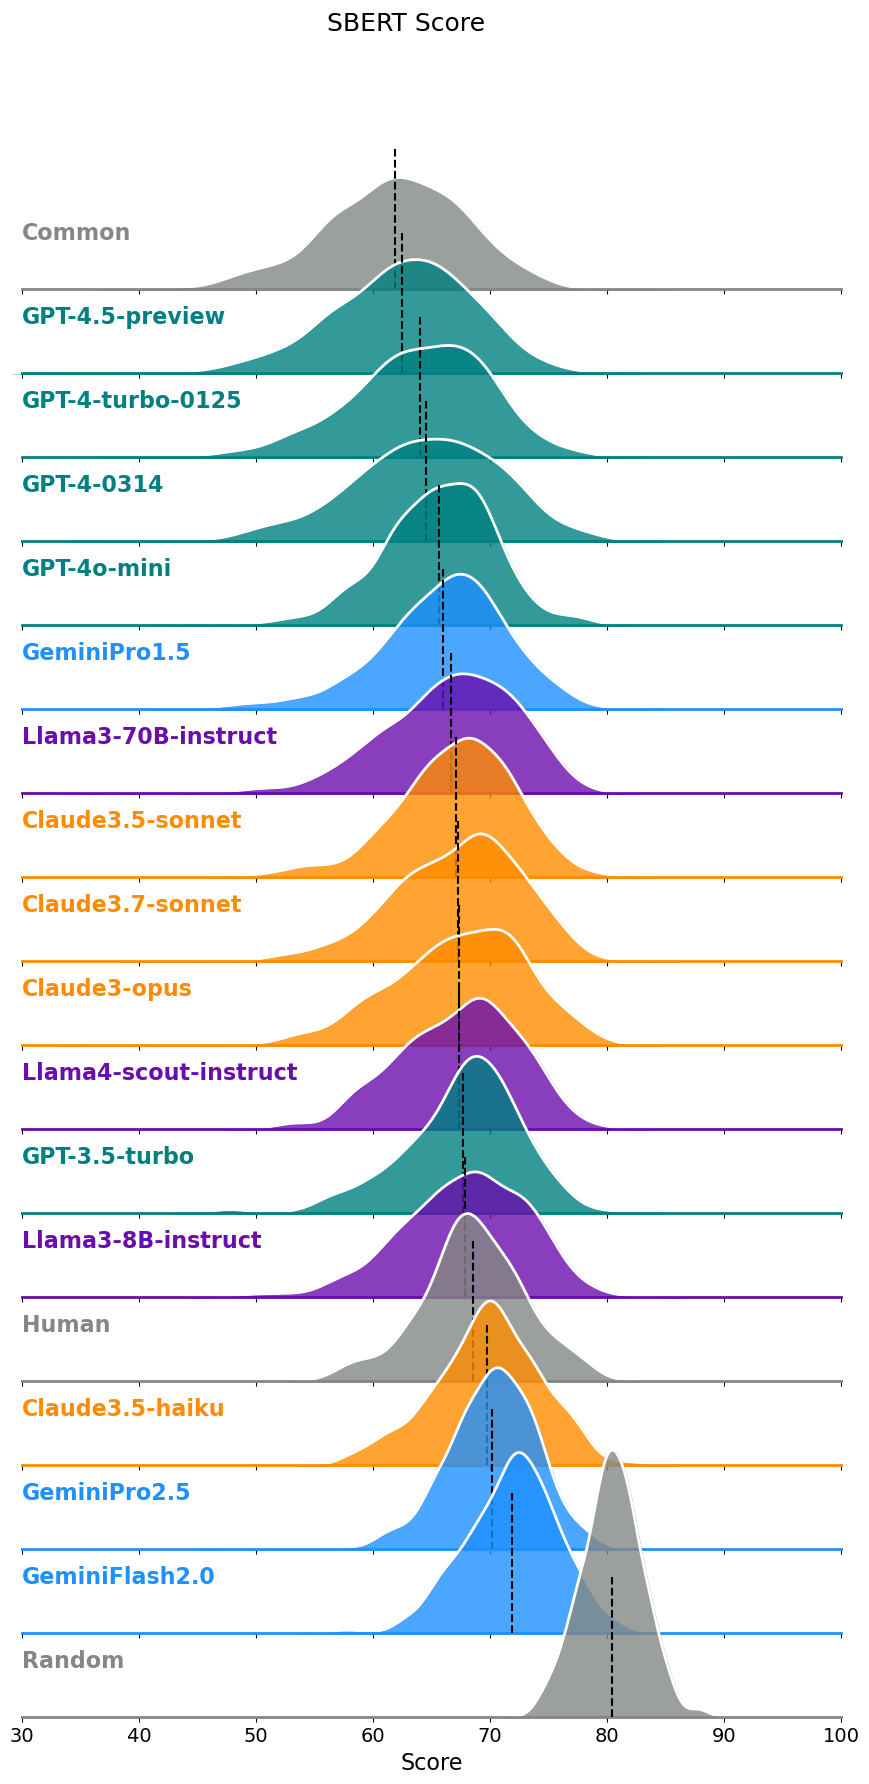

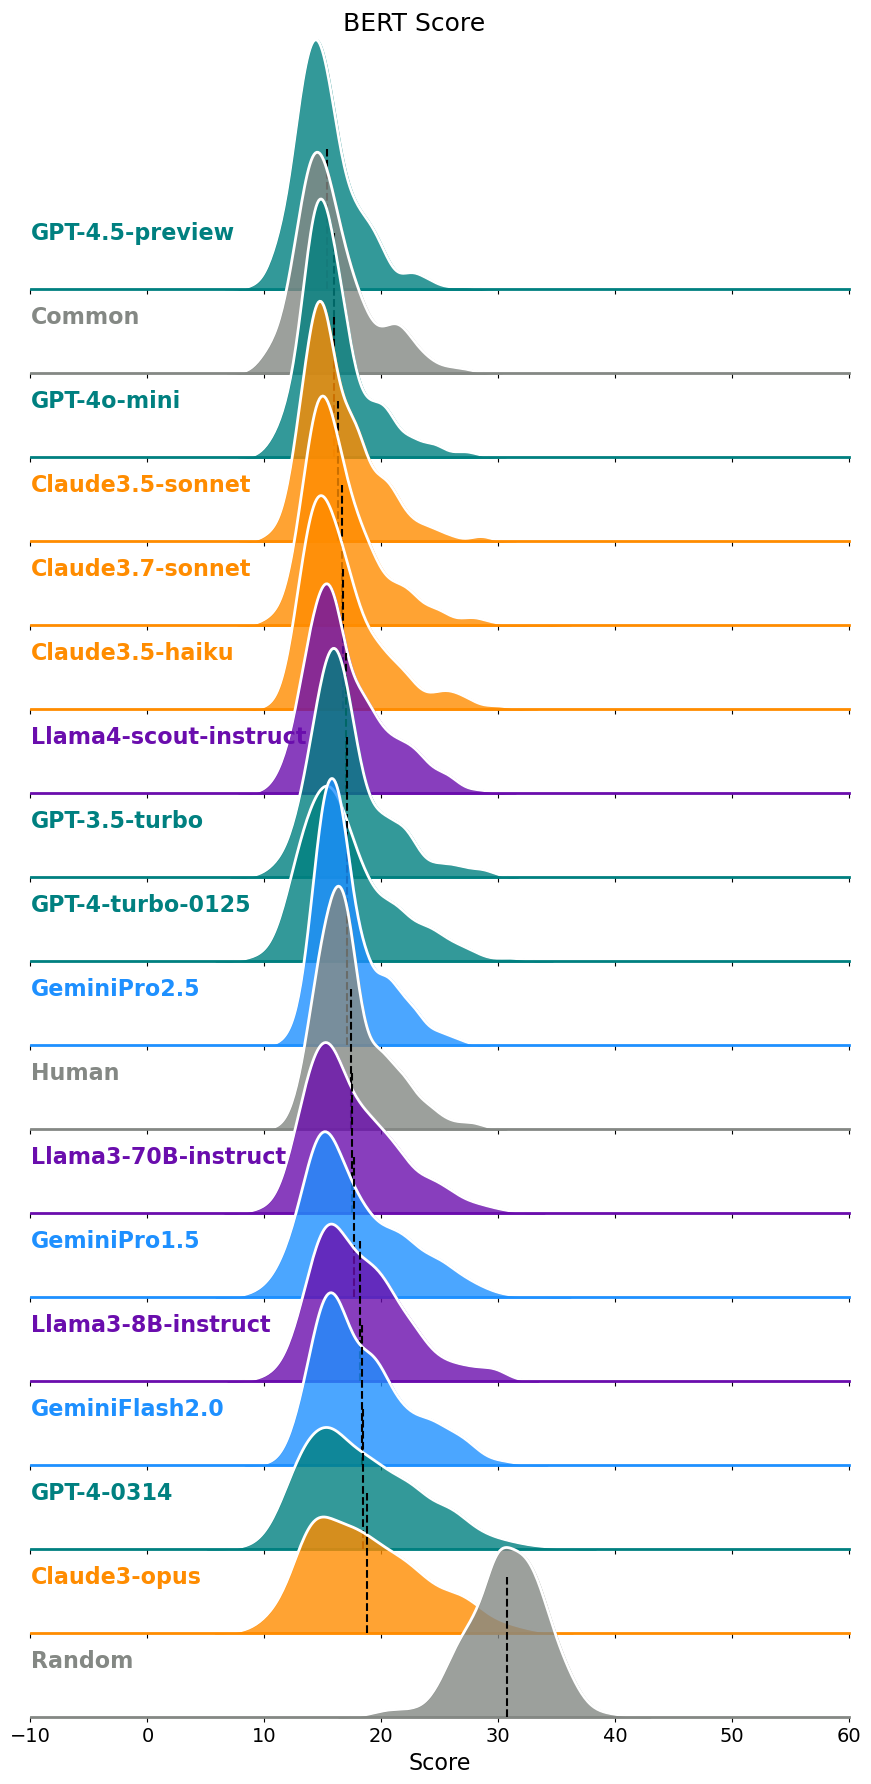

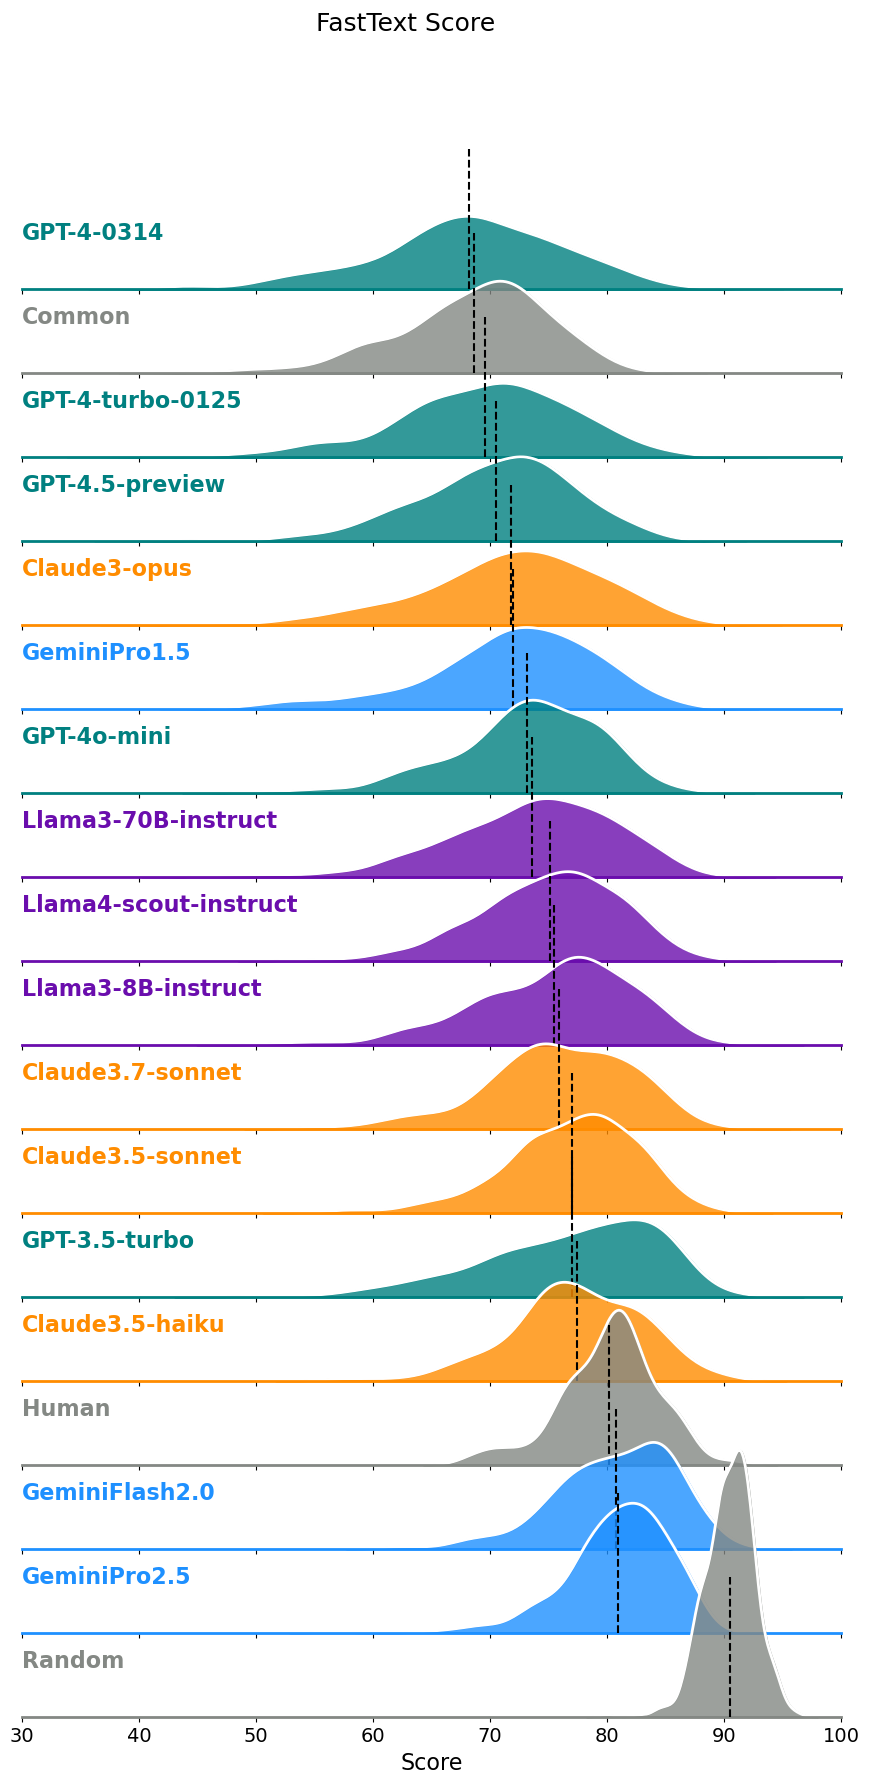

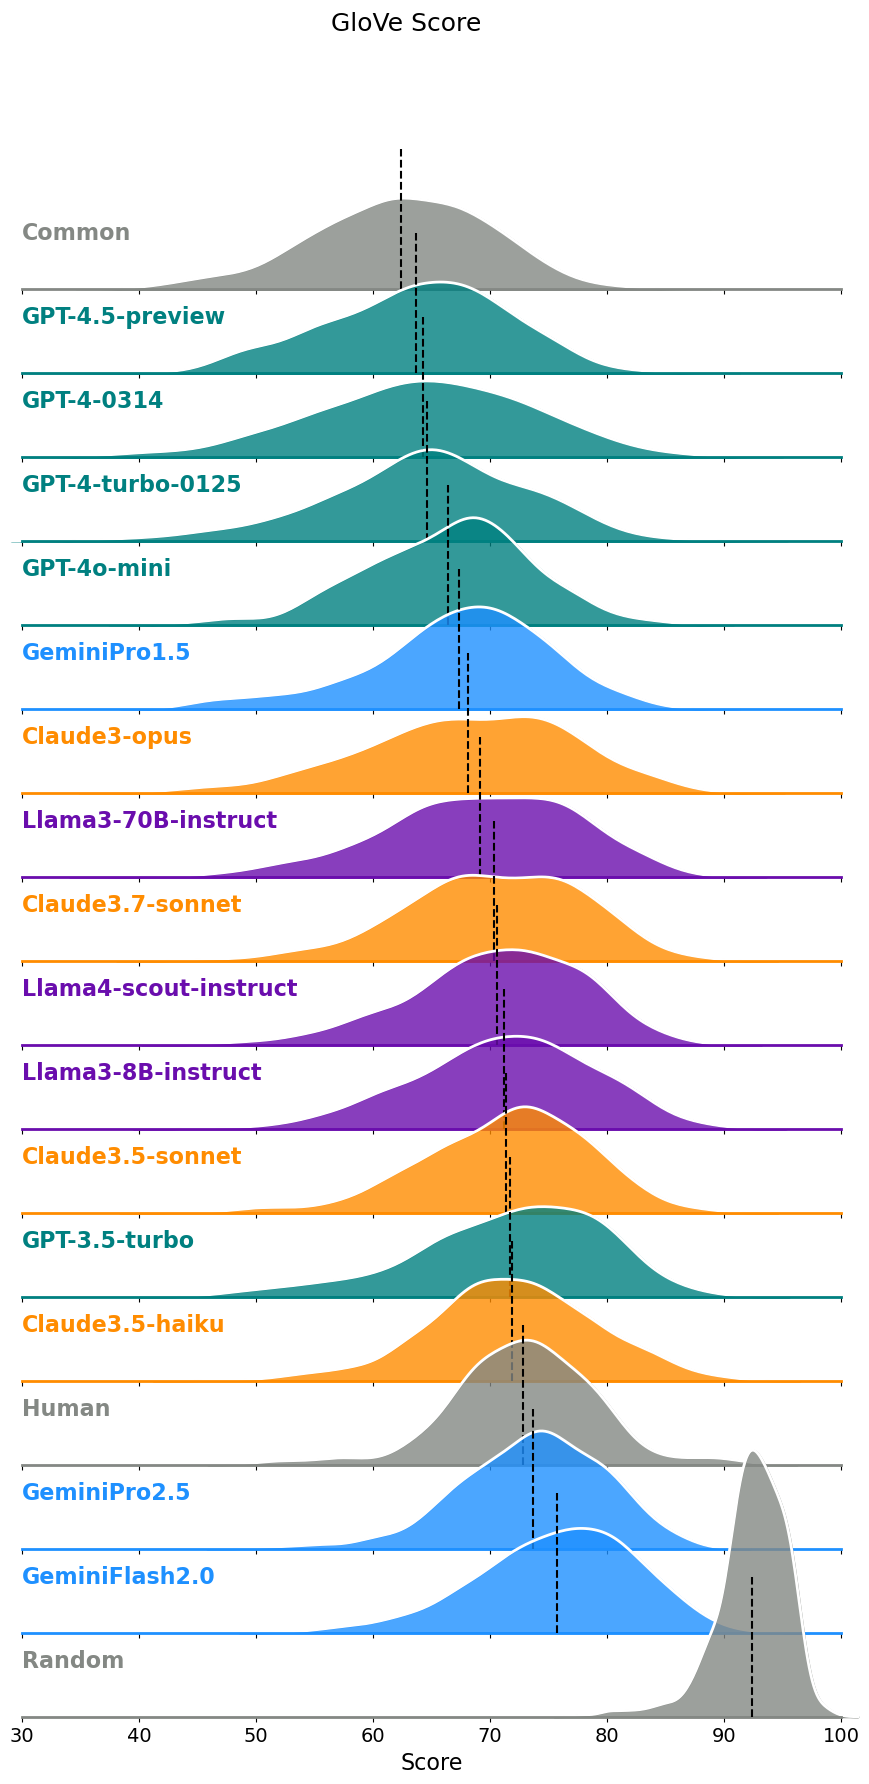

In [24]:
# Code was adapted from: https://github.com/AntoineBellemare/DAT_GPT/tree/main
# Generate ridge plots (overlapping density distributions) for each novelty metric
# This visualization shows the distribution of novelty scores for each model
for novelty_type in novelty_types:
    
    # Filter data: select mid-temperature condition for LLMs, plus baseline conditions
    temp_df = results_df.loc[(results_df['Temperature']=='Mid')]
    df = pd.concat([temp_df, human_df, random_df, common_df])
    
    # Keep only models in the predefined list and remove rows with missing novelty scores
    df = df[df['Model'].isin(models)]
    df = df.dropna(subset=[novelty_type])
    
    # Order models by mean novelty score (ascending) for consistent visualization
    order = df.groupby('Model')[novelty_type].mean().sort_values(ascending=True).index
    
    # Create color palette dictionary mapping each model to its assigned color
    color_dict_ridge = {model: colors[f'{model}_mid'] for model in models}
    
    # Sort color palette to match the model ordering
    pal = [color_dict_ridge[model] for model in order]
    
    # Initialize FacetGrid for creating ridge plot (one row per model)
    g = sns.FacetGrid(df, row="Model", hue="Model", aspect=9, height=1, row_order=order, palette=pal, hue_order=order)
    
    # Configure axes: transparent background and no grid for clean ridge plot appearance
    for ax in g.axes.flat:
        ax.set_facecolor('none')
        ax.grid(False)
    
    # Draw density distributions in two steps for visual effect
    g.map(sns.kdeplot, novelty_type,
          bw_adjust=1, clip_on=False,
          fill=True, alpha=0.8, linewidth=1.5)
    g.map(sns.kdeplot, novelty_type, clip_on=False, color="w", lw=2, bw_adjust=1)
    
    # Add reference line at y=0 (baseline) using hue mapping for color consistency
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)
    
    # Define function to add model labels to each subplot
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes, fontsize=16)
    g.map(label, novelty_type)
    
    # Perform statistical analysis: compute means, confidence intervals, p-values, and effect sizes
    mean_conf, pvals, tvals, cohen_d = analyze_results(df, 'Model', order, metric=novelty_type)
    
    # Extract mean values for each model (used for vertical reference lines)
    for model in order:
        median_val = mean_conf[mean_conf['Model'] == model]['mean'].values[0]
    
    # Add vertical dashed lines indicating mean novelty score for each model
    for ax, model in zip(g.axes.flat, order):
        ax.axvline(mean_conf[mean_conf['Model'] == model]['mean'].values[0], 
                   color='black', linestyle='--', ymin=0, ymax=0.5)
    
    # Format x-axis labels
    for ax in g.axes.flat:
        ax.set_xlabel('Score', fontsize=16)
        for label in ax.get_xticklabels():
            label.set_fontsize(14)
    
    # Remove default titles and configure overlapping subplot layout for ridge plot effect
    g.set_titles("")
    g.figure.subplots_adjust(hspace=-.7)  # Negative spacing creates overlapping effect
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

    # Add main title indicating which embedding method is being visualized
    g.fig.suptitle(f'{novelty_labels[novelty_type]} Score', fontsize=18, y=0.98)
    
    # Set x-axis limits based on embedding type (BERT has different score range)
    if novelty_type == 'bert_lavg_novelty':
        g.set(xlim=(-10, 60))
    else:
        g.set(xlim=(30, 100))
    
    # Save figure with high resolution for publication
    save_path_ridge = FIGURE_PATH / f'DAT_LLMs_humans_ridge_{novelty_labels[novelty_type].lower()}_final'
    g.savefig(save_path_ridge, dpi=300)

### Novelty Ranking Stats

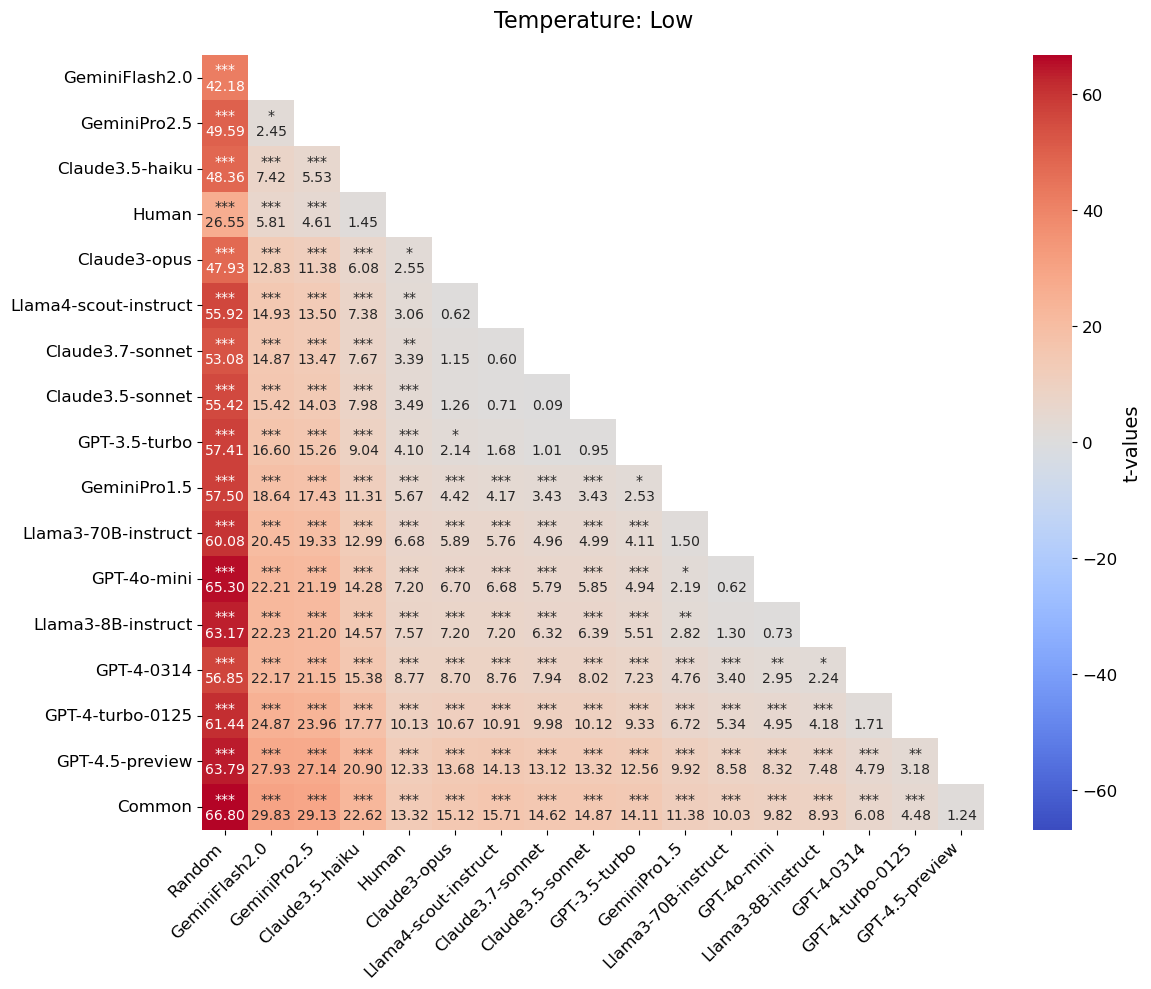

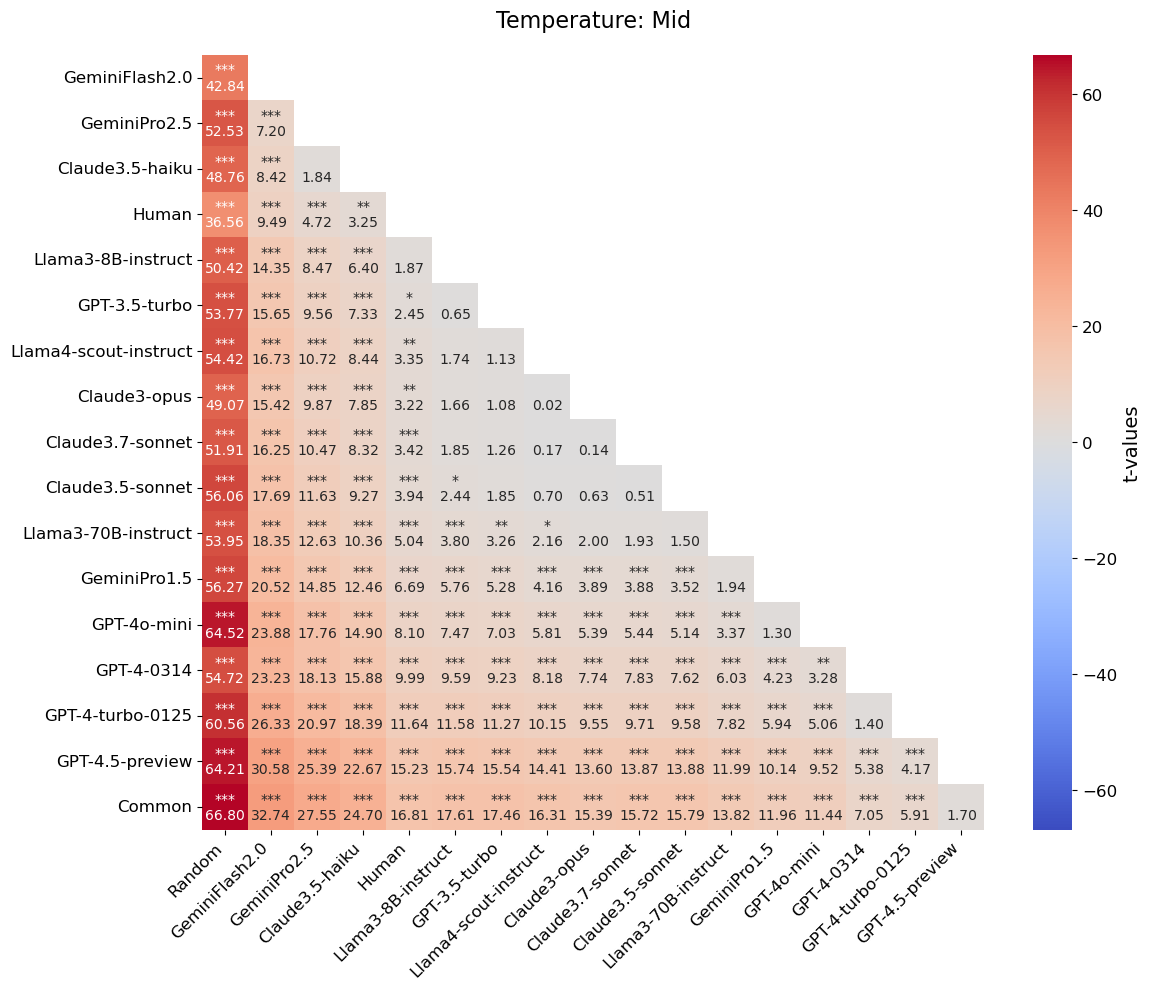

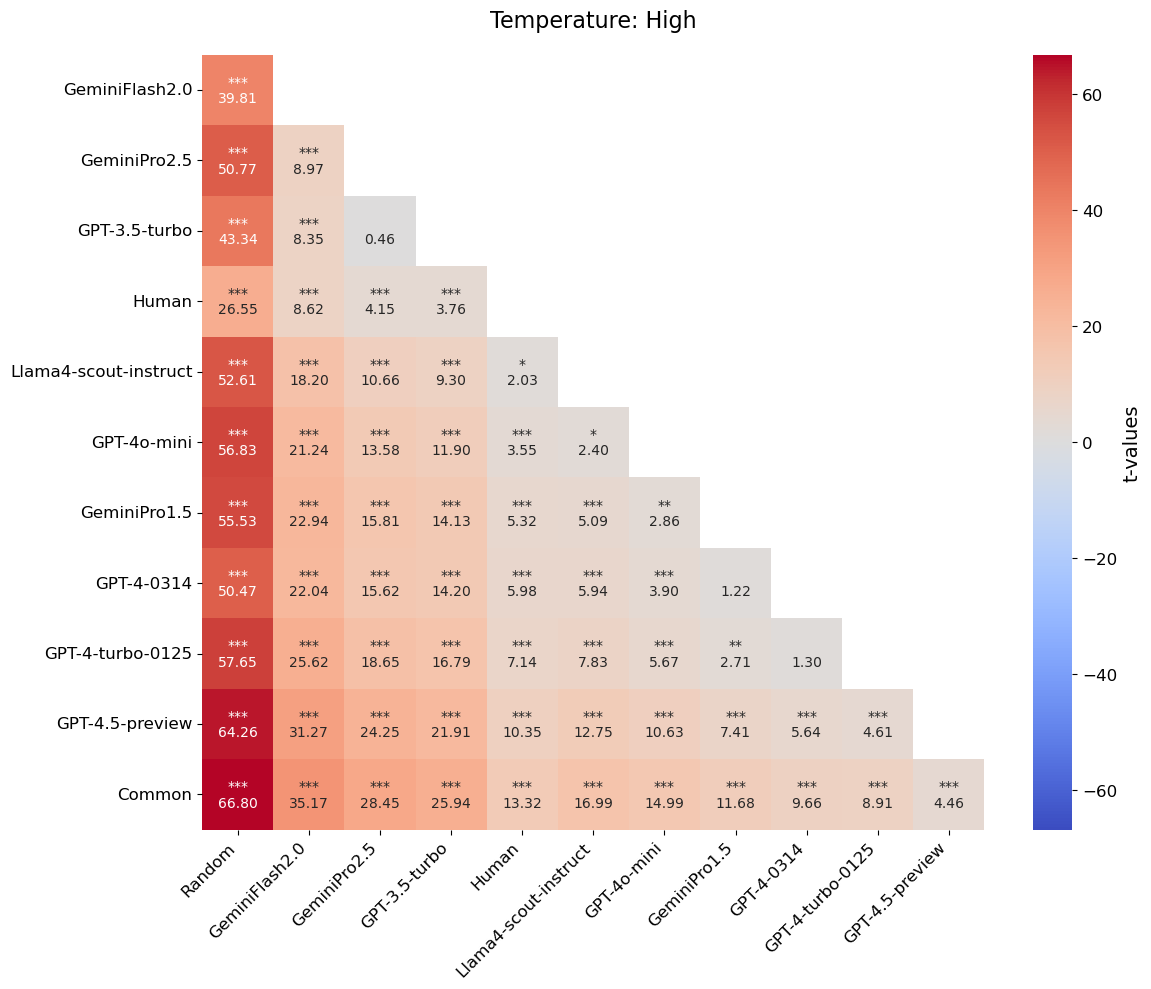

In [26]:
# Code was adapted from: https://github.com/AntoineBellemare/DAT_GPT/tree/main

temperatures = ['Low', 'Mid', 'High']

# Create heatmaps for each temperature
for temp in temperatures:

    # Get data for current temperature
    temp_data = pd.concat([results_df[results_df['Temperature'] == temp], human_df, random_df, common_df])
    
    # Determine which models to include based on temperature
    if temp == 'High':
        models_to_plot = high_models
    else:
        models_to_plot = models
    
    # Filter data to only include models we want to plot
    temp_data = temp_data[temp_data['Model'].isin(models_to_plot)]
    
    # Create order based on mean divergence score (highest to lowest)
    order = temp_data.groupby('Model')['sbert_novelty'].mean().sort_values(ascending=False).index.tolist()
    
    # Analyze results for this temperature
    mean_conf, pvals, tvals, cohen_d = analyze_results(temp_data, 'Model', order, metric='sbert_novelty')
    
    # Create heatmap only (no bar plot)
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(tvals, dtype=bool))
    
    # Prepare heatmap annotations
    mask = mask[1:, :-1]
    heatmap_data = tvals.iloc[1:, :-1]
    pval_stars = pvals.iloc[1:, :-1].applymap(
        lambda x: "***" if x < 0.001 else "**" if x < 0.01 else "*" if x < 0.05 else ""
    )
    annotations = heatmap_data.applymap(lambda x: f"\n{x:.2f}")
    combined_annot = pval_stars + annotations
    
    # Create heatmap
    sns.heatmap(
        heatmap_data,
        mask=mask,
        annot=combined_annot,
        fmt="",
        cmap="coolwarm",
        cbar_kws={"label": "t-values"},
        ax=ax,
        vmin=-heatmap_data.abs().max().max(),
        vmax=heatmap_data.abs().max().max(),
        linewidths=0,
        annot_kws={'size': 10}
    )
    
    # Customize the heatmap
    ax.set_title(f'Temperature: {temp}', fontsize=16, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.tick_params(labelsize=12)
    
    # Customize colorbar
    colorbar = ax.collections[0].colorbar
    colorbar.ax.tick_params(labelsize=12)
    colorbar.set_label("t-values", fontsize=14)
    
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f'cdat_divergence_contrasts_{temp}.png', dpi=300, bbox_inches='tight')
    plt.show()

## Pareto Fronts

In [67]:
def pareto_front(x, y, maximize=(False, False)):
    """
    Compute Pareto front indices.
    
    Parameters:
        x, y : numpy arrays
            The two objectives (same length).
        maximize : tuple of bools
            Whether to maximize each objective. 
            E.g., (True, False) maximizes x and minimizes y.
            
    Returns:
        indices of points on the Pareto front
    """
    points = np.column_stack((x, y))

    # Flip objectives for maximization (convert to minimization)
    if maximize[0]:
        points[:, 0] = -points[:, 0]
    if maximize[1]:
        points[:, 1] = -points[:, 1]

    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, point in enumerate(points):
        if is_pareto[i]:

            # Keep only those not dominated
            # points[is_pareto] < point checks if any dimension is less than the current point
            # np.any(..., axis=1) returns True if at least one dimension is less than the current point
            is_pareto[is_pareto] = np.any(points[is_pareto] < point, axis=1)
            
            # Each point stays in the Pareto front unless it's actually dominated by another point
            # Self-comparison doesn't eliminate points that should be in the Pareto front
            is_pareto[i] = True  # Keep self

    return np.where(is_pareto)[0] # returns the indices of the points on the Pareto front

# Add small random jitter to separate overlapping points
def add_jitter(x, y, amount=0.2):
    return (x + np.random.normal(0, amount, size=len(x)), 
            y + np.random.normal(0, amount, size=len(y)))

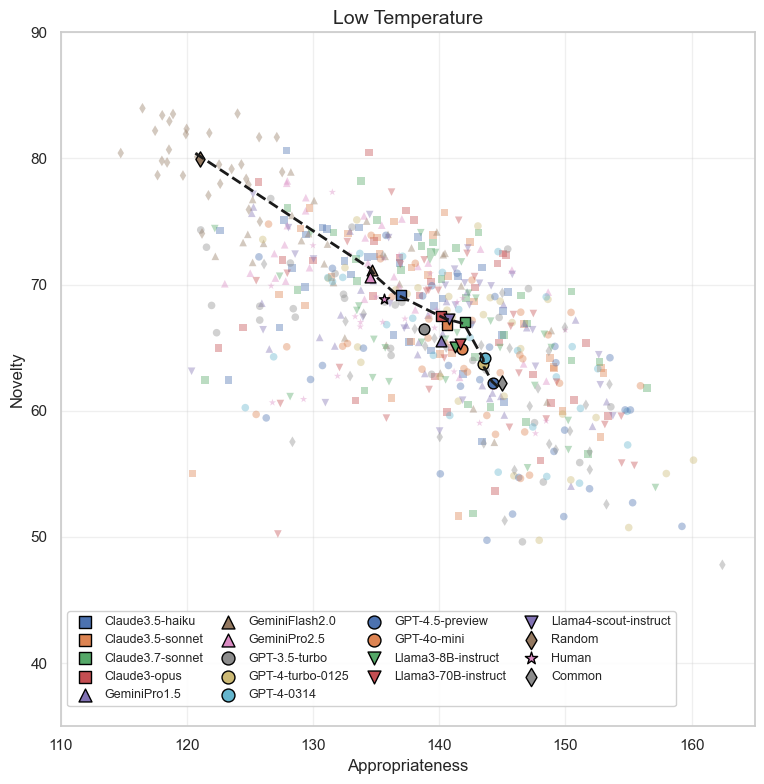

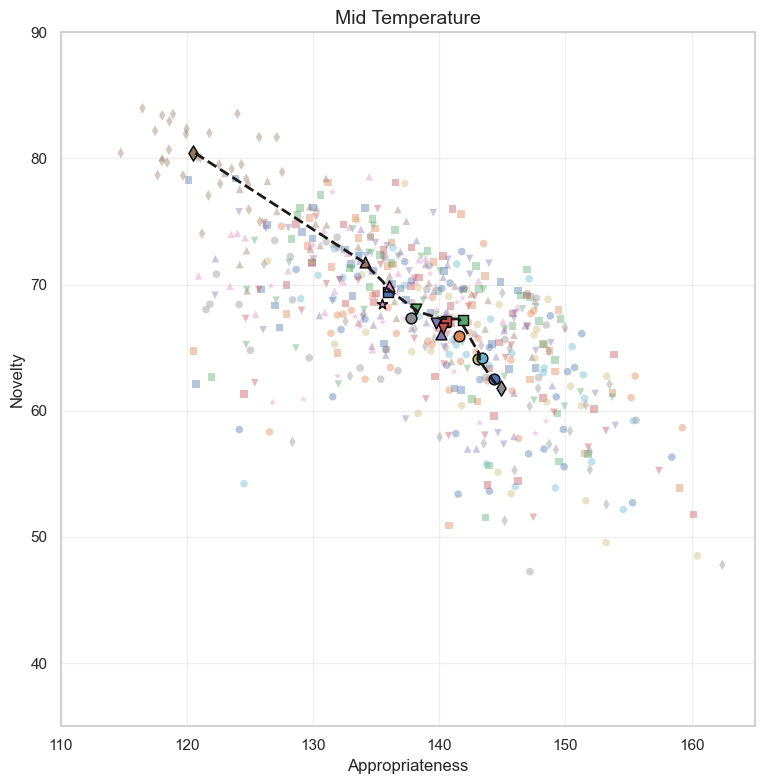

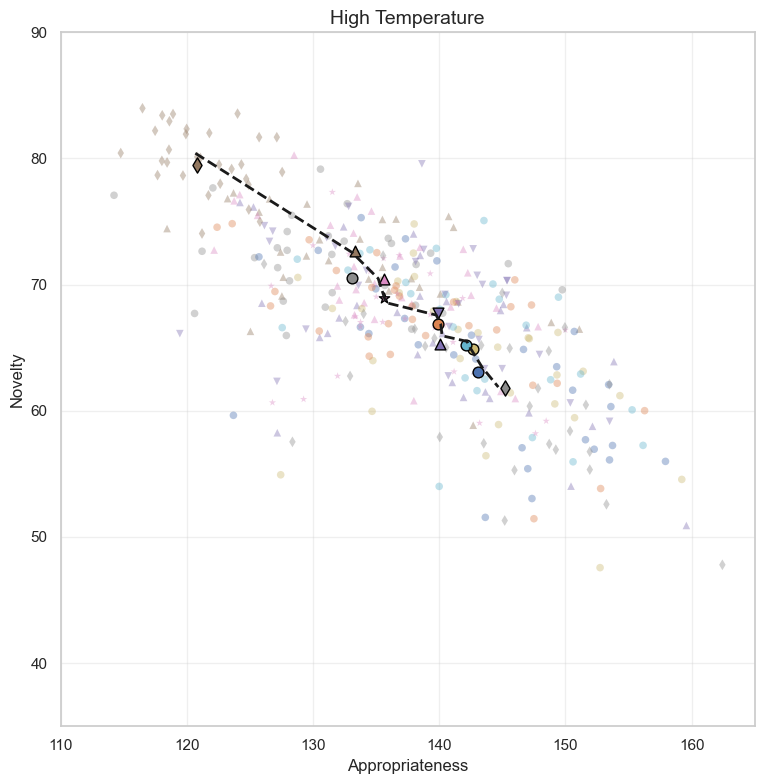

In [ ]:
# Generate Pareto front visualizations for each temperature condition
# Pareto fronts show the optimal trade-off between appropriateness and novelty
temperatures = ['Low', 'Mid', 'High']
titles = [f"Temperature: {temp}" for temp in temperatures]

# Create separate figures for each temperature
for temp in temperatures:
    fig = plt.figure(figsize=(10, 8))  
    ax = fig.add_subplot(111, aspect='equal')  

    # Select models to plot based on temperature condition
    # High temperature uses a subset of models, others use full model list
    if temp == 'High':
        models_to_plot = high_models
    else:
        models_to_plot = models
    
    # Combine temperature-specific data with baseline conditions (Human, Random, Common)
    temp_data = pd.concat([results_df[results_df['Temperature'] == temp], human_df, random_df, common_df])
    
    # Optional: Extract subset of data points for plotting individual responses
    # Using first 20 points per model to avoid overcrowding the visualization
    plot_data = pd.concat([temp_data[temp_data['Model'] == model].head(20) for model in models_to_plot])
    
    # Calculate mean appropriateness and novelty scores for each model
    # These averages are used to determine Pareto-optimal models
    avg_by_model = temp_data.groupby('Model').agg({
        'sbert_appropriateness': 'mean',
        'sbert_novelty': 'mean'
    })

    # Optional: Plot individual data points as background (semi-transparent)
    # Shows the distribution of individual responses for each model
    for model in models_to_plot:
        model_data = temp_data[temp_data['Model'] == model].head(30)
        ax.scatter(model_data['sbert_appropriateness'],
                  model_data['sbert_novelty'],
                  color=color_dict[model], 
                  s=30,  # Smaller markers for individual points
                  alpha=0.4,  # Semi-transparent to show density
                  marker=get_marker(model) if not model == 'Human' else '*',
                  edgecolors='none',
                  label=model)

    # Plot average points (more prominent) and collect legend handles
    # Average points represent each model's overall performance
    legend_handles = []
    for model in models_to_plot:
        # Add small random jitter to prevent overlapping points
        x_jittered, y_jittered = add_jitter(
            np.array([avg_by_model.loc[model, 'sbert_appropriateness']]),
            np.array([avg_by_model.loc[model, 'sbert_novelty']]),
            amount=0.25
        )

        # Plot average point with model-specific marker and color
        scatter = ax.scatter(x_jittered, y_jittered,
                  color=color_dict[model], 
                  s=60,  # Larger markers for averages
                  alpha=1.0,  # Fully opaque
                  marker=get_marker(model) if not model == 'Human' else '*',
                  edgecolors='black',  # Black border for visibility
                  linewidth=1,
                  label=model)  
        legend_handles.append(scatter)

    # Calculate Pareto front: models that are not dominated by any other model
    # A model is Pareto-optimal if no other model has both higher appropriateness AND higher novelty
    avg_by_model = avg_by_model.loc[models_to_plot]
    indices = pareto_front(avg_by_model['sbert_appropriateness'].values, 
                          avg_by_model['sbert_novelty'].values, 
                          maximize=(True, True))  # Maximize both objectives

    # Extract Pareto-optimal points and sort by appropriateness for smooth line
    pareto_x = avg_by_model['sbert_appropriateness'].values[indices]
    pareto_y = avg_by_model['sbert_novelty'].values[indices]
    
    # Sort Pareto points by x-coordinate for proper line plotting
    sorted_indices = np.argsort(pareto_x)
    pareto_x = pareto_x[sorted_indices]
    pareto_y = pareto_y[sorted_indices]

    # Plot Pareto front as dashed line connecting optimal models
    ax.plot(pareto_x, pareto_y, 'k--', label='Pareto Front', linewidth=2)
    
    # Set fixed axis limits for consistent comparison across temperatures
    ax.set_ylim(35, 90, auto=False)
    ax.set_xlim(110, 165, auto=False)
    ax.set_xlabel('Appropriateness', fontsize=12)
    ax.set_ylabel('Novelty', fontsize=12)
    ax.set_title(f"{temp} Temperature", fontsize=14)
    ax.grid(True, alpha=0.3)

    # Add legend only for Low and Mid temperatures
    if temp == 'Low':
        # Calculate number of columns needed (approximately 5 models per column)
        num_models = len(models_to_plot)
        num_columns = (num_models + 4) // 5  # Round up division
        
        ax.legend(handles=legend_handles, 
                 loc='lower left',
                 bbox_to_anchor=(0.00, 0.02),
                 ncol=num_columns,  # Dynamic number of columns
                 fontsize=9,
                 markerscale=1.2,
                 columnspacing=1.0,
                 handletextpad=0.6,
                 framealpha=0.9,
                 borderaxespad=0.5)
    
    # Adjust layout to prevent overlap and save figure
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f'cdat_pareto_front_cos_{temp}_appropriatedness_novelty.png', dpi=300, bbox_inches='tight')
    plt.show()

# 3. Appendix

## Elbow Distance

In [68]:
# Define metrics for cosine-based appropriateness and novelty
METRICS_COS = ['sbert_appropriateness', 'sbert_novelty']

def calculate_distance_to_line(x, y, x1, y1, x2, y2):
    """
    Calculate perpendicular distance from point (x, y) to line defined by points (x1, y1) and (x2, y2).
    
    This computes the "elbow distance" - the signed perpendicular distance from a model's individual responses
    (appropriateness, novelty) point to the baseline trade-off line connecting average responses of Common and Random baselines.
    
    Positive values indicate the model exceeds the trivial novelty-appropriateness trade-off
    (better performance than baseline). Negative values indicate below-baseline performance.
    
    The line represents the trivial trade-off between appropriateness and novelty established
    by the Common (high appropriateness, low novelty) and Random (low appropriateness, high novelty) baselines.
    """
    # Perpendicular distance formula: |(y2-y1)(x-x1) - (x2-x1)(y-y1)| / sqrt((x2-x1)² + (y2-y1)²)
    # Signed distance (positive = above line, negative = below line)
    numerator = (y2 - y1) * (x - x1) - (x2 - x1) * (y - y1)
    denominator = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return numerator / denominator if denominator != 0 else 0

# Initialize storage for results across all temperature conditions
temp_results = []
temp_stats = {}
temp_df = pd.DataFrame()

# Process each temperature condition separately
for temp in ['Low', 'Mid', 'High']:
    # Combine temperature-specific data with baseline conditions
    # Includes Human responses and baseline models (Common, Random) for comparison
    temp_df = pd.concat([
        results_df[results_df['Temperature'] == temp],
        results_df[results_df['Model'] == 'Human'],
        results_df[results_df['Model'] == 'Common'],
        results_df[results_df['Model'] == 'Random']
    ]).copy()

    # Calculate mean appropriateness and novelty for each model at this temperature
    avg_metrics = temp_df.groupby('Model').agg({
        'sbert_appropriateness': 'mean',
        'sbert_novelty': 'mean'
    }).reset_index()
    
    # Extract baseline points: Common (high appropriateness, low novelty) and Random (low appropriateness, high novelty)
    # These define the trivial trade-off line
    common_cos = avg_metrics[avg_metrics['Model'] == 'Common'][['sbert_appropriateness', 'sbert_novelty']].iloc[0]
    random_cos = avg_metrics[avg_metrics['Model'] == 'Random'][['sbert_appropriateness', 'sbert_novelty']].iloc[0]
    
    # Identify Pareto-optimal models: models not dominated by any other model
    # Pareto models represent the optimal trade-off frontier
    pareto_indices = pareto_front(
        avg_metrics['sbert_appropriateness'].values,
        avg_metrics['sbert_novelty'].values,
        maximize=(True, True)  # Maximize both appropriateness and novelty
    )
    pareto_models = avg_metrics.iloc[pareto_indices]['Model'].tolist()
    
    print(f"\nPareto models for {temp} temperature:")
    print(pareto_models)
    
    # Calculate elbow distances for Pareto-optimal models only
    # Elbow distance measures deviation from the trivial baseline trade-off line
    def calculate_distances(row):
        # Compute perpendicular distance from model point to Common-Random baseline line
        cos_dist = calculate_distance_to_line(
            row['sbert_appropriateness'], row['sbert_novelty'],
            common_cos['sbert_appropriateness'], common_cos['sbert_novelty'],
            random_cos['sbert_appropriateness'], random_cos['sbert_novelty']
        )
        return pd.Series({'cos_distance': cos_dist})
    
    # Filter to Pareto models and calculate distances for all their responses
    pareto_df = temp_df[temp_df['Model'].isin(pareto_models)].copy()
    distances = pareto_df.apply(calculate_distances, axis=1)
    pareto_df['cos_distance'] = distances['cos_distance']
    
    # Calculate summary statistics (mean and std) for each Pareto model
    temp_agg = (
        pareto_df
        .groupby('Model')
        .agg(
            cos_distance_mean=('cos_distance', 'mean'),
            cos_distance_std=('cos_distance', 'std')
        )
        .reset_index()
    )

    # Remove outliers using 3-sigma rule (keep values within 3 standard deviations of mean)
    # This ensures robust statistical analysis by excluding extreme values
    pareto_df_cos = pareto_df.groupby('Model').apply(
        lambda x: x[np.abs(x['cos_distance'] - x['cos_distance'].mean()) <= 3 * x['cos_distance'].std()]
    ).reset_index(drop=True).copy()

    # Perform statistical analysis comparing elbow distances between Pareto models
    # Compares models that exceed the trivial novelty-appropriateness trade-off
    mean_conf_cos, pvals_cos, tvals_cos, cohen_d_cos = analyze_results(
        pareto_df_cos, 'Model', pareto_models, metric='cos_distance'
    )

    # Store statistics for this temperature
    temp_stats[temp] = {
        'mean_conf': mean_conf_cos,
        'pvals': pvals_cos,
        'tvals': tvals_cos,
        'cohen_d': cohen_d_cos
    }

    # Add temperature label and append to results
    temp_agg['Temperature'] = temp
    temp_results.append(temp_agg)

# Combine results from all temperatures into single dataframe
agg = pd.concat(temp_results, ignore_index=True)

# Set up plotting style and color palette for visualization
sns.set(style='whitegrid')
TEMP_PALETTE = {'Low': '#512eb7', 'Mid': '#dbba25', 'High': '#f44a2f', 'N/A': '#bdbdbd'}


Pareto models for Low temperature:
['Claude3-opus', 'Claude3.5-haiku', 'Claude3.7-sonnet', 'Common', 'GPT-4-0314', 'GPT-4-turbo-0125', 'GPT-4.5-preview', 'GeminiFlash2.0', 'GeminiPro2.5', 'Random']

Pareto models for Mid temperature:
['Claude3-opus', 'Claude3.5-haiku', 'Claude3.7-sonnet', 'Common', 'GPT-4-0314', 'GPT-4-turbo-0125', 'GPT-4.5-preview', 'GeminiFlash2.0', 'GeminiPro2.5', 'Llama3-8B-instruct', 'Llama4-scout-instruct', 'Random']

Pareto models for High temperature:
['Common', 'GPT-4-0314', 'GPT-4-turbo-0125', 'GPT-4.5-preview', 'GPT-4o-mini', 'GeminiFlash2.0', 'GeminiPro1.5', 'GeminiPro2.5', 'Human', 'Llama4-scout-instruct', 'Random']


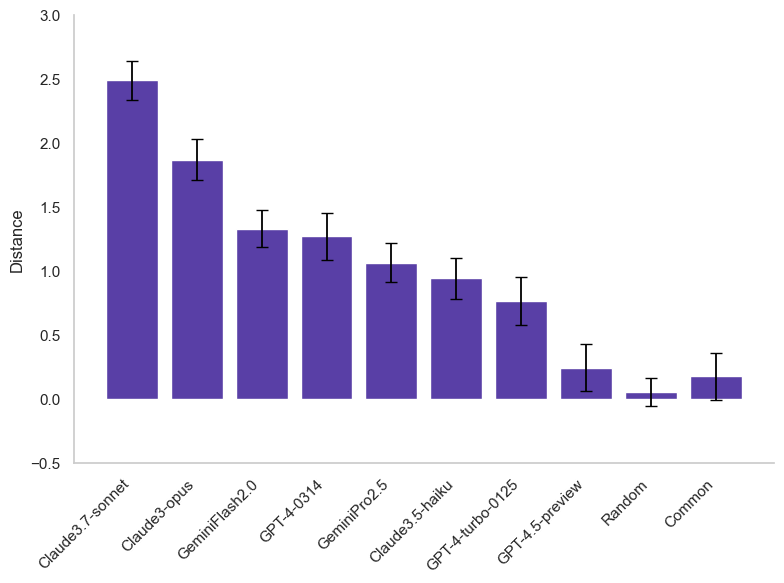

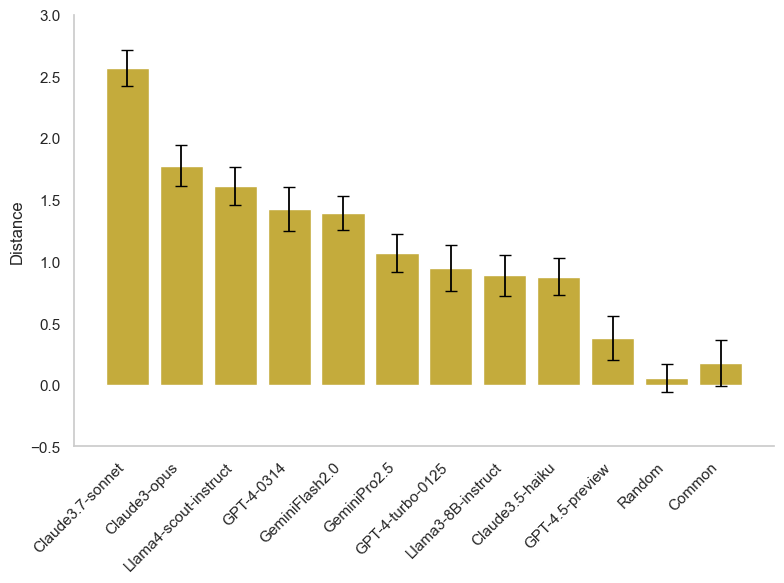

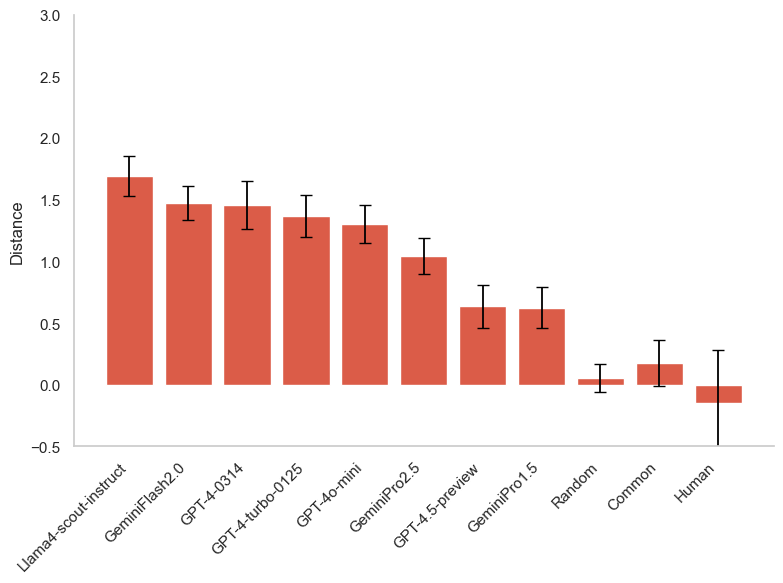

In [ ]:
# Create separate plots for each temperature
for temp in ['Low', 'Mid', 'High']:
    # Create single subplot for current temperature
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Get stored results for current temperature
    temp_data = temp_stats[temp]
    mean_conf = temp_data['mean_conf']
    pvals_table = temp_data['pvals']
    
    # Define custom sorting order
    model_order = {model: idx for idx, model in enumerate(['Random', 'Common', 'Human'])}
    mean_conf['sort_order'] = mean_conf['Model'].map(lambda x: model_order.get(x, -1))
    mean_conf = mean_conf.sort_values(['sort_order', 'mean'], ascending=[True, False])
    mean_conf = mean_conf.drop('sort_order', axis=1)
    
    # Get the order of models for plotting
    order = mean_conf['Model'].tolist()
    
    # Create bar plot with single color for all Paretomodels in this temperature
    bar_plot = sns.barplot(
        x='Model',
        y='mean',
        data=mean_conf,
        ax=ax,
        color=TEMP_PALETTE[temp],  # Use single color for all models in this temperature
        order=order,
        errorbar=None,
    )
    
    # Add error bars using sem from mean_conf
    for i, (_, row) in enumerate(mean_conf.iterrows()):
        ax.errorbar(
            x=i,
            y=row['mean'],
            yerr=row['sem'],
            fmt='none',
            capsize=4,
            color='black',
            lw=1.3
        )
    
    ax.set_ylabel('Distance')
    ax.xaxis.label.set_visible(False)
    ax.set_ylim(-0.5, 3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Remove grid lines
    ax.grid(False)
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f'cdat_elbow_distance_{temp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Distance to the Human Average

Human average cosine metrics:
sbert_appropriateness    135.775029
sbert_novelty             68.571365
dtype: float64


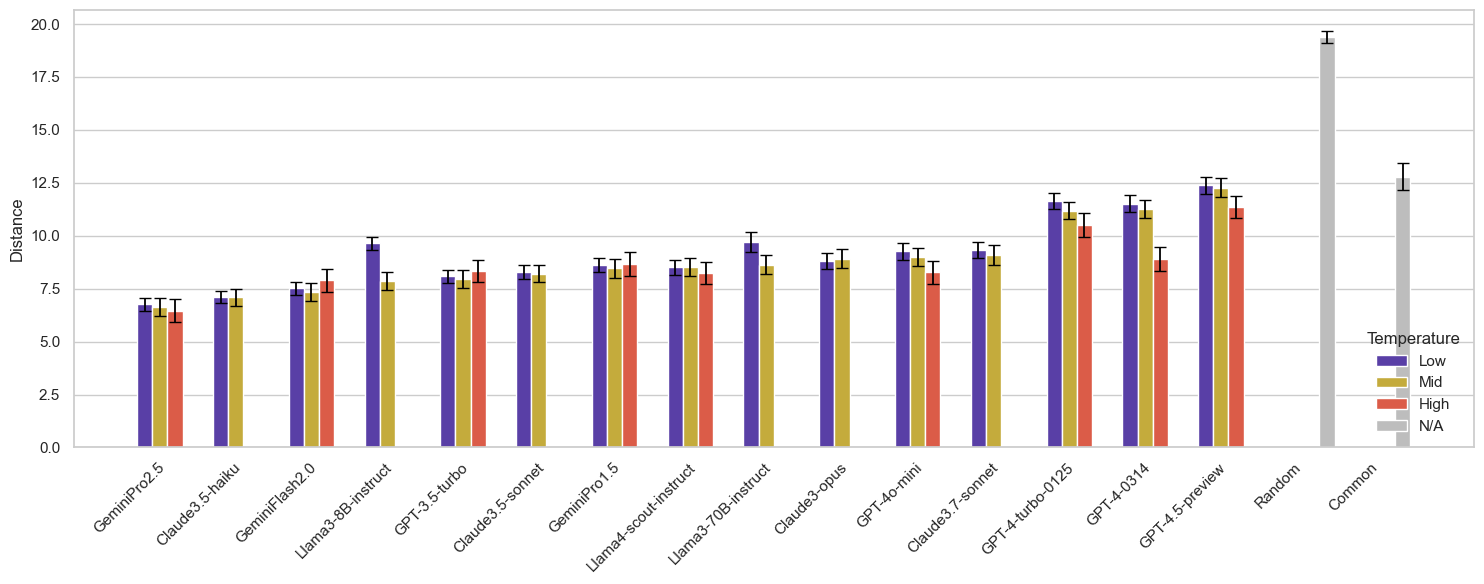

In [ ]:
# Define metrics for cosine-based appropriateness and novelty
METRICS_COS = ['sbert_appropriateness', 'sbert_novelty']

def euclid(a, b):
    """Calculate Euclidean distance between two points."""
    return np.sqrt(np.square(a - b).sum(axis=1))

def calculate_mean_conf(df, grouping_key, metric):
    """
    Calculate mean and confidence intervals for plotting.
    Uses 95% confidence intervals (1.96 * SEM).
    """
    mean_conf = df.groupby(grouping_key)[metric].agg(["mean", "median", "sem", "std"])
    mean_conf["ci_low"] = mean_conf["mean"] - 1.96 * mean_conf["sem"]
    mean_conf["ci_high"] = mean_conf["mean"] + 1.96 * mean_conf["sem"]
    mean_conf["1std"] = mean_conf["mean"] + mean_conf["std"]
    mean_conf["-1std"] = mean_conf["mean"] - mean_conf["std"]
    mean_conf.reset_index(inplace=True)
    return mean_conf

# Calculate human average appropriateness and novelty scores
# This represents humans' implicit balance between novelty and appropriateness
human_mask = results_df['Model'] == 'Human'
human_avg_cos = results_df.loc[human_mask, METRICS_COS].mean()

print("Human average cosine metrics:")
print(human_avg_cos)

# Prepare data: calculate Euclidean distances from each model's responses to human average
# We compare distances to the human average to identify models that align more closely 
# with humans' implicit novelty-appropriateness balance
df = results_df.copy()
df['Dist_cos'] = euclid(df[METRICS_COS], human_avg_cos)

# Set temperature to 'N/A' for baseline models (Human, Random, Common)
df.loc[df['Model'].isin(['Random', 'Common']), 'Temperature'] = 'N/A'
# Exclude Human from analysis 
df = df[df['Model'].ne('Human')]

# Remove outliers using 3-sigma rule (keep values within 3 standard deviations of mean)
# Applied separately for each model-temperature combination
df_cos = df.groupby(['Model', 'Temperature']).apply(
    lambda x: x[np.abs(x['Dist_cos'] - x['Dist_cos'].mean()) <= 3 * x['Dist_cos'].std()]
).reset_index(drop=True)

# Calculate mean and confidence intervals for plotting grouped by Model and Temperature
agg = calculate_mean_conf(df_cos, ['Model', 'Temperature'], 'Dist_cos')

agg = agg.rename(columns={
    'mean': 'Dist_cos_mean',
    'std': 'Dist_cos_std',
    'sem': 'Dist_cos_sem',
    'ci_low': 'Dist_cos_ci_low',
    'ci_high': 'Dist_cos_ci_high',
    '1std': 'Dist_cos_1std',
    '-1std': 'Dist_cos_minus1std'
})

sns.set(style='whitegrid')
PALETTE = {'Low': '#512eb7', 'Mid': '#dbba25', 'High': '#f44a2f', 'N/A': '#bdbdbd'}

col = 'cos'
mean_col = f'Dist_{col}_mean'
ci_low_col = f'Dist_{col}_ci_low'
ci_high_col = f'Dist_{col}_ci_high'

# Determine model order: sort by mean distance at Mid temperature (closest to human = best)
mid_temp_data = agg[agg['Temperature'] == 'Mid']
current_order = mid_temp_data.sort_values(mean_col)['Model'].tolist()
# Add baseline models (Random, Common) if not already in the order
current_order = current_order + [m for m in ['Random', 'Common'] if m not in current_order]

fig, ax = plt.subplots(figsize=(15, 6))

# Sort data for plotting: models in order, temperatures sorted within each model
sorted_agg = pd.DataFrame()
for model in current_order:
    model_data = agg[agg['Model'] == model]
    # Sort temperatures: Low, Mid, High, N/A
    temp_order = {'Low': 0, 'Mid': 1, 'High': 2, 'N/A': 3}
    model_data = model_data.sort_values('Temperature', key=lambda x: x.map(temp_order))
    sorted_agg = pd.concat([sorted_agg, model_data])

# Create bar plot showing mean distances by model and temperature
barplot = sns.barplot(
    data=sorted_agg,
    x='Model', y=mean_col, hue='Temperature',
    palette=PALETTE, ci=None, ax=ax,
    order=current_order,
    hue_order=['Low', 'Mid', 'High', 'N/A']
)

# Extract bar positions and heights for error bar placement
bar_positions = []
bar_heights = []
for container in barplot.containers:
    for bar in container:
        bar_positions.append(bar.get_x() + bar.get_width() / 2)
        bar_heights.append(bar.get_height())

# Add confidence interval error bars
for i, (_, row) in enumerate(sorted_agg.iterrows()):
    ci_range = row[ci_high_col] - row[ci_low_col]
    ax.errorbar(
        x=bar_positions[i],
        y=bar_heights[i],
        yerr=ci_range/2,  # Half the CI range for symmetric error bars
        fmt='none',
        capsize=4,
        color='black',
        lw=1.3
    )

ax.xaxis.label.set_visible(False)
ax.set_ylabel('Distance', fontsize=12) 
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Format legend to show only temperatures present in data
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), 
         title='Temperature', 
         loc='lower right', 
         frameon=False)

plt.tight_layout()
plt.savefig(FIGURE_PATH / f'cdat_distance_to_human_{col}_low.png', dpi=300, bbox_inches='tight')
plt.show()

### Temperature Comparison

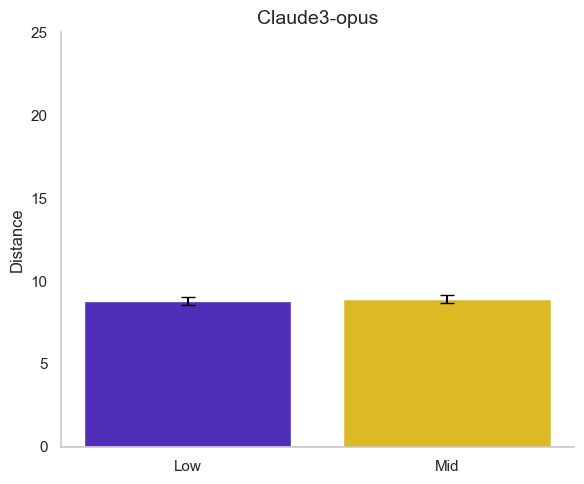

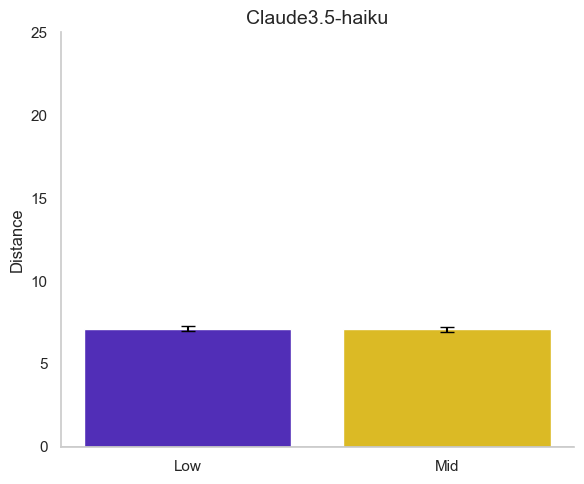

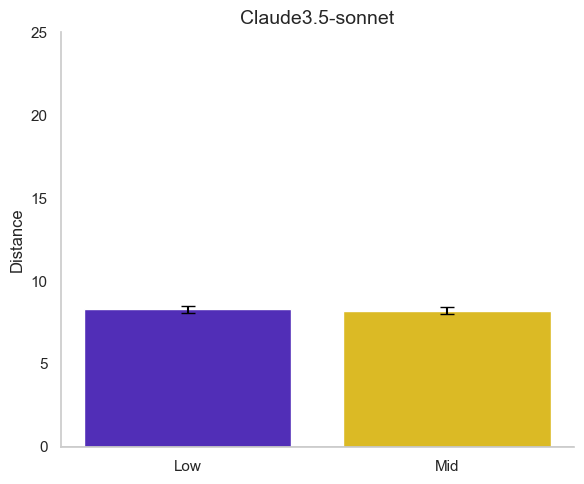

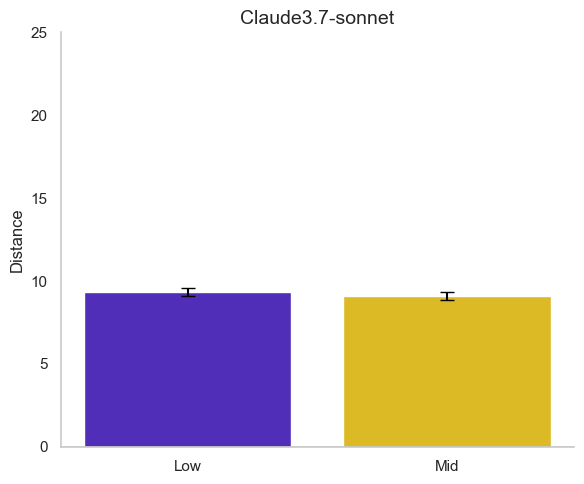

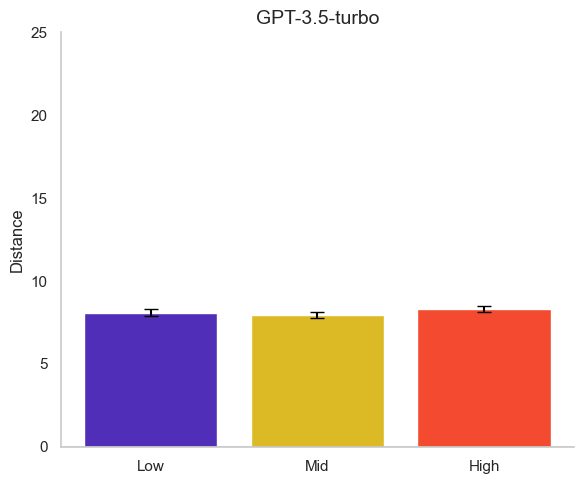

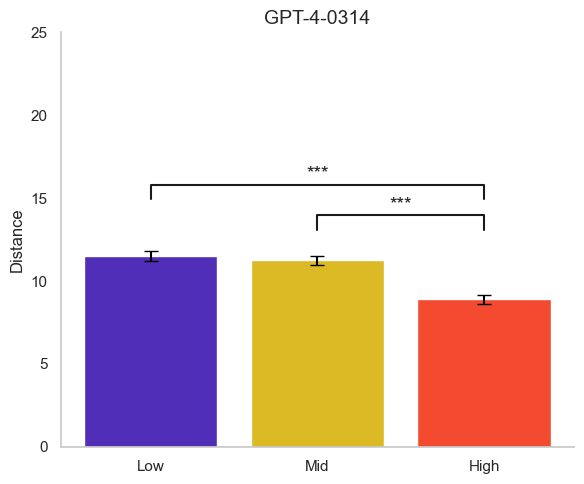

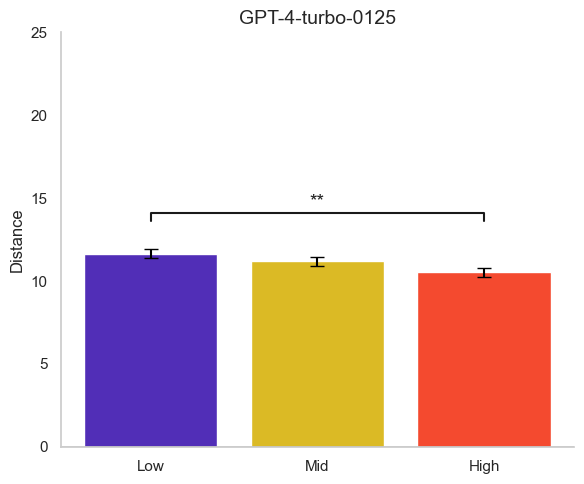

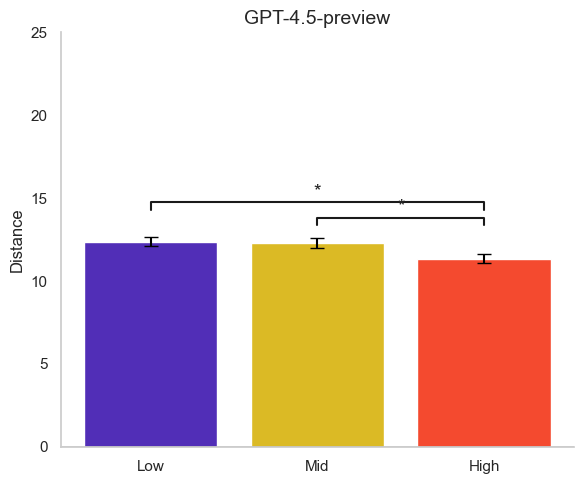

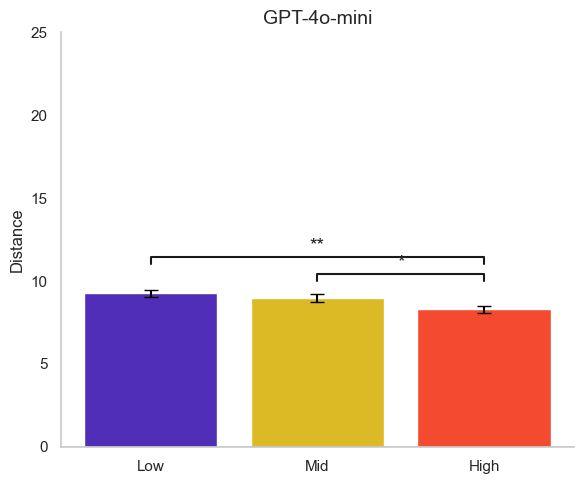

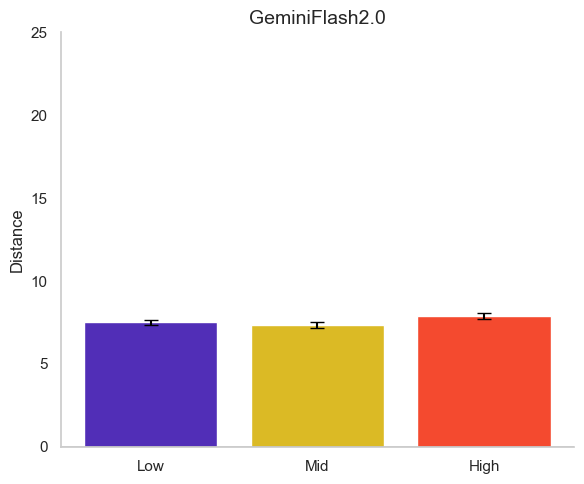

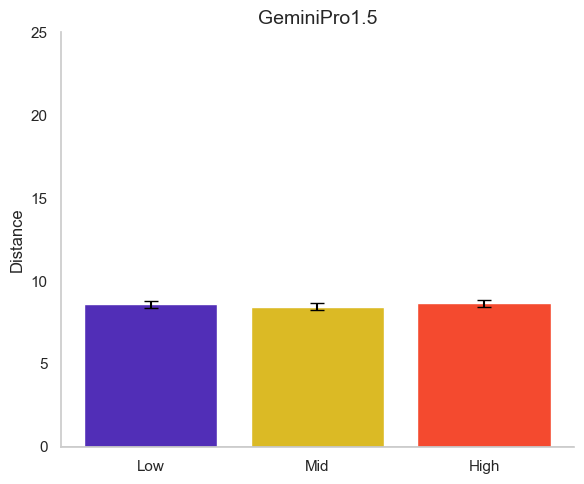

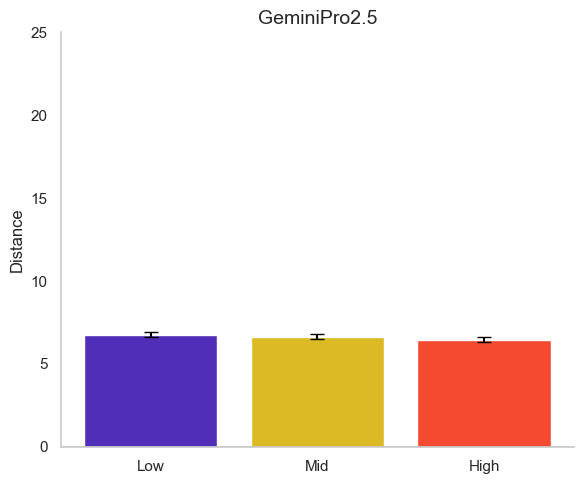

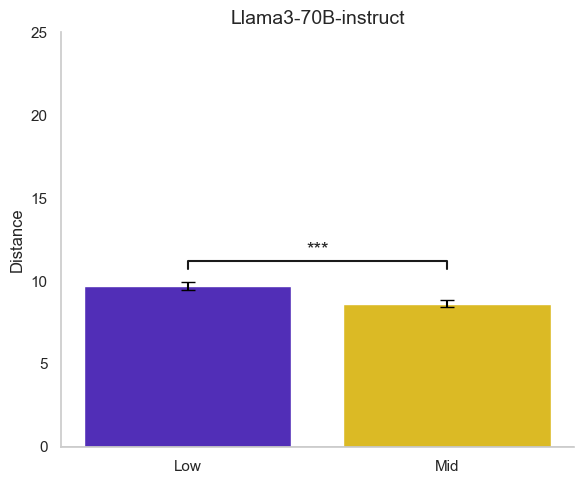

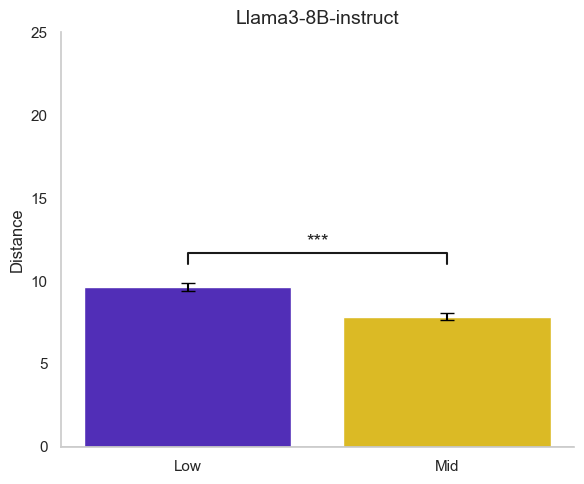

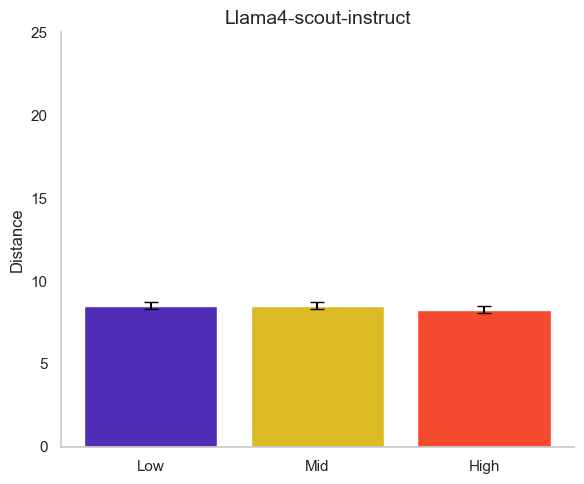

In [ ]:
# Temperature effect analysis: identifies whether temperature settings affect how closely models align with human responses

# Set up plotting style
sns.set(style='whitegrid')
PALETTE = {'Low': '#512eb7', 'Mid': '#dbba25', 'High': '#f44a2f', 'N/A': '#bdbdbd'}

# Get models to analyze (exclude baseline models Random and Common)
models = [m for m in df_cos['Model'].unique() if m not in ['Random', 'Common']]

# Create individual plot for each model showing temperature effects
for model in models:
    # Extract aggregated statistics for current model from pre-calculated agg dataframe
    model_agg = agg[agg['Model'] == model].copy()
    
    # Get available temperatures (excluding N/A) and sort in order: Low, Mid, High
    temperatures = sorted([t for t in model_agg['Temperature'].unique() if t != 'N/A'], 
                         key=lambda x: {'Low': 0, 'Mid': 1, 'High': 2}.get(x, 999))
    
    # Skip models with fewer than 2 temperature conditions (insufficient for comparison)
    if len(temperatures) < 2:
        continue
    
    # Filter and sort statistics for available temperatures
    # Uses pre-calculated means and SEMs from agg dataframe
    stats = model_agg[model_agg['Temperature'].isin(temperatures)].copy()
    stats = stats.sort_values('Temperature', key=lambda x: x.map({'Low': 0, 'Mid': 1, 'High': 2}))
    
    # Perform pairwise t-tests between temperature conditions
    # Uses cleaned df_cos data to compare distance distributions across temperatures
    
    model_df = df_cos[df_cos['Model'] == model].copy()
    pvals = {}
    for i, temp1 in enumerate(temperatures):
        for j, temp2 in enumerate(temperatures):
            if j <= i:
                continue
            # Extract distance values for each temperature condition
            data1 = model_df[model_df['Temperature'] == temp1]['Dist_cos'].dropna()
            data2 = model_df[model_df['Temperature'] == temp2]['Dist_cos'].dropna()
            if len(data1) > 0 and len(data2) > 0:
                # Independent samples t-test
                _, pval = stats.ttest_ind(data1, data2)
                pvals[(temp1, temp2)] = pval
    
    # Apply Benjamini-Hochberg FDR correction for multiple comparisons
    # Controls false discovery rate across all pairwise temperature comparisons
    if pvals:
        pvals_list = list(pvals.values())
        _, pvals_corrected, _, _ = sms.multipletests(pvals_list, alpha=0.05, method='fdr_bh')
        pvals_corrected_dict = dict(zip(pvals.keys(), pvals_corrected))
    else:
        pvals_corrected_dict = {}
    
    # Create bar plot showing mean distance to human average for each temperature
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Plot bars with temperature-specific colors
    bars = ax.bar(range(len(stats)), stats['Dist_cos_mean'], 
                   color=[PALETTE[t] for t in stats['Temperature']],
                   error_kw={'capsize': 5})
    
    # Add error bars showing standard error of the mean (SEM)
    ax.errorbar(range(len(stats)), stats['Dist_cos_mean'], yerr=stats['Dist_cos_sem'],
                fmt='none', color='black', capsize=5, lw=1.5)
    
    # Add significance bridges between significantly different temperature pairs
    # Bridges connect bars with asterisks indicating significance level
    bar_tops = (stats['Dist_cos_mean'] + stats['Dist_cos_sem']).values
    base_offset = (max(bar_tops) - min(bar_tops)) * 0.8 + 0.5
    
    for i, temp1 in enumerate(temperatures):
        for j, temp2 in enumerate(temperatures):
            if j <= i:
                continue
            key = (temp1, temp2)
            if key in pvals_corrected_dict and pvals_corrected_dict[key] < 0.05:
                # Determine significance level: *** p < 0.001, ** p < 0.01, * p < 0.05
                p = pvals_corrected_dict[key]
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*'
                
                # Draw horizontal bridge connecting the two bars
                offset = base_offset * (j - i) * 0.6
                y = max(bar_tops[i], bar_tops[j]) + offset
                ax.plot([i, i, j, j], [y, y + base_offset/3, y + base_offset/3, y], 
                       lw=1.5, c='k')
                # Add significance stars above the bridge
                ax.text((i + j) / 2, y + base_offset/3 + 0.1, stars,
                       ha='center', va='bottom', fontsize=14)
    
    # Format plot axes and labels
    ax.set_xticks(range(len(stats)))
    ax.set_xticklabels(stats['Temperature'], rotation=0)
    ax.set_ylabel('Distance', fontsize=12)  # Distance to human average in appropriateness-novelty space
    ax.set_title(model, fontsize=14)
    ax.set_ylim(0, 25)
    ax.set_yticks(np.arange(0, 26, 5))
    ax.grid(False)
    ax.axhline(y=0, color='black', linewidth=1)
    sns.despine(ax=ax, top=True, right=True)
    
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f'human_distance_{model}_temperature_cos.png', dpi=300, bbox_inches='tight')
    plt.show()

## Embedding Sensitivity Analysis

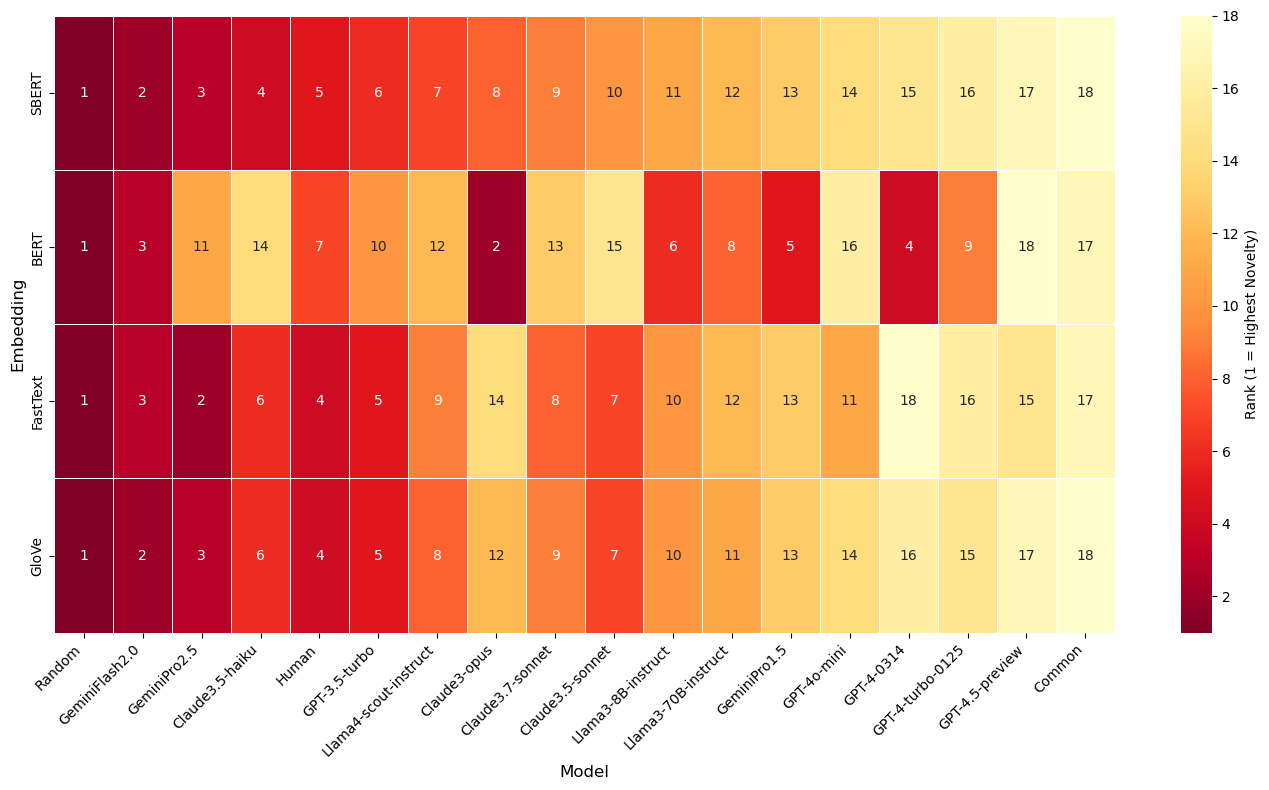

In [48]:
# Create heatmap of model rankings between embedding types
plt.figure(figsize=(14, 8))

# Calculate model means including all models (Random and Common baselines included)
df_work = results_df.copy()
model_means = df_work.groupby('Model')[novelty_types].mean()
model_means = model_means.dropna()

# Calculate rankings for each embedding type (1 = highest novelty)
model_rankings_df = pd.DataFrame()
for novelty_type in novelty_types:
    # Rank in descending order (highest score = rank 1)
    model_rankings_df[novelty_type] = model_means[novelty_type].rank(ascending=False, method='average')

# Sort models by SBERT ranking for consistent ordering (lowest rank number = highest novelty)
sorted_models = model_rankings_df.sort_values('sbert_novelty', ascending=True).index

# Create display dataframe with labels
display_rankings = model_rankings_df.loc[sorted_models].copy()
display_rankings.columns = [novelty_labels[col] for col in display_rankings.columns]

# Convert to integers (round first to handle ties properly)
display_rankings_int = display_rankings.round().astype(int)

# Use reversed colormap - darker = higher rank (lower rank number = higher novelty)
# Since rank 1 is best (highest novelty), we want darker colors for smaller numbers
sns.heatmap(display_rankings_int.T, 
            annot=True, 
            fmt='d',  # Display as integers
            cmap='YlOrRd_r',  # Reversed: darker for lower rank numbers (higher novelty)
            linewidths=0.5,
            cbar_kws={'label': 'Rank (1 = Highest Novelty)'},
            square=False)  # Allow rectangular cells for better fit
plt.ylabel('Embedding', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./figures_revise/model_novelty_rankings_heatmap_bert_lavg_final.png', dpi=300, bbox_inches='tight')
plt.show()

### Spearman Rank Correlation

In [ ]:
def compute_ranking_correlations(df, novelty_types, novelty_labels):
    """
    Compute Spearman rank correlations between different embedding methods' novelty rankings.
    Baseline models (Random and Common) are excluded from the analysis.
    """
    
    # Create working copy and exclude baseline models (Random and Common)
    df_work = df.copy()
    df_work = df_work[~df_work['Model'].isin(['Random', 'Common'])]
    
    # Calculate mean novelty scores per model for each embedding type
    model_means = df_work.groupby('Model')[novelty_types].mean()
    model_means = model_means.dropna()  # Remove models with missing data
    
    print(f"\nRanking Correlation Analysis (Excluding Random & Common)")
    print("="*80)
    print(f"Number of models: {len(model_means)}")
    print(f"Models: {', '.join(model_means.index.tolist())}\n")
    
    # Create rankings for each embedding type (rank 1 = highest novelty)
    # Rankings are computed in descending order: highest score gets rank 1
    rankings = {}
    for novelty_type in novelty_types:
        rankings[novelty_type] = model_means[novelty_type].rank(ascending=False, method='average')
    
    # Compute Spearman rank correlations between all pairs of embedding methods
    # Spearman correlation measures monotonic relationships between rankings
    correlation_results = []
    for (type1, type2) in itertools.combinations(novelty_types, 2):
        rho, p_value = stats.spearmanr(rankings[type1], rankings[type2])
        correlation_results.append({
            'Embedding1': novelty_labels[type1],
            'Embedding2': novelty_labels[type2],
            'Spearman_rho': rho,
            'p_value': p_value,
            'n_models': len(rankings[type1])
        })
        print(f"{novelty_labels[type1]} vs {novelty_labels[type2]}:")
        print(f"  ρ = {rho:.4f}, p = {p_value:.4f}, n = {len(rankings[type1])} models")
    
    return correlation_results, rankings, model_means

# Prepare data: filter to mid-temperature condition and convert novelty scores to numeric
df = results_df.copy()
df = df[df['Temperature'] == 'Mid']

# Convert novelty score columns to numeric (handle any non-numeric values)
for col in novelty_types:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute ranking correlations (baselines are always excluded)
results_without, rankings_without, means_without = compute_ranking_correlations(
    df, novelty_types, novelty_labels
)


Ranking Correlation Analysis (Excluding Random & Common)
Number of models: 16
Models: Claude3-opus, Claude3.5-haiku, Claude3.5-sonnet, Claude3.7-sonnet, GPT-3.5-turbo, GPT-4-0314, GPT-4-turbo-0125, GPT-4.5-preview, GPT-4o-mini, GeminiFlash2.0, GeminiPro1.5, GeminiPro2.5, Human, Llama3-70B-instruct, Llama3-8B-instruct, Llama4-scout-instruct

SBERT vs BERT:
  ρ = 0.2618, p = 0.3274, n = 16 models
SBERT vs FastText:
  ρ = 0.8882, p = 0.0000, n = 16 models
SBERT vs GloVe:
  ρ = 0.9471, p = 0.0000, n = 16 models
BERT vs FastText:
  ρ = -0.0824, p = 0.7617, n = 16 models
BERT vs GloVe:
  ρ = 0.1088, p = 0.6883, n = 16 models
FastText vs GloVe:
  ρ = 0.9676, p = 0.0000, n = 16 models


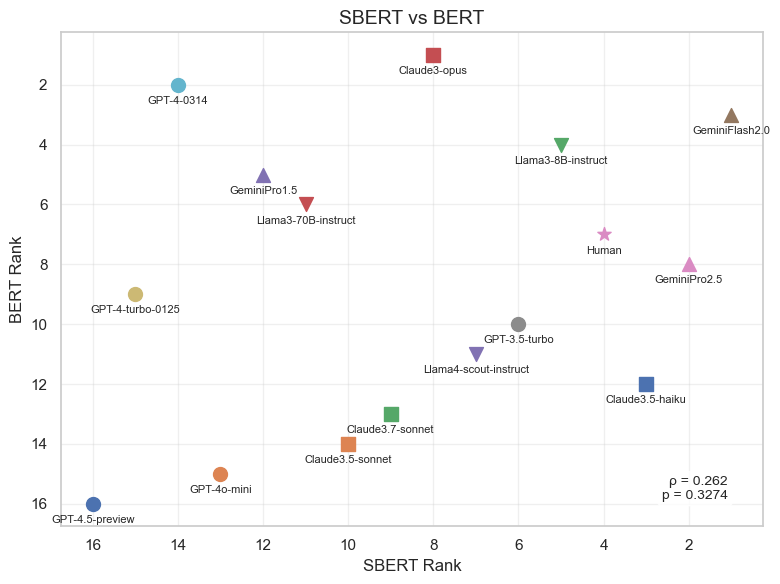

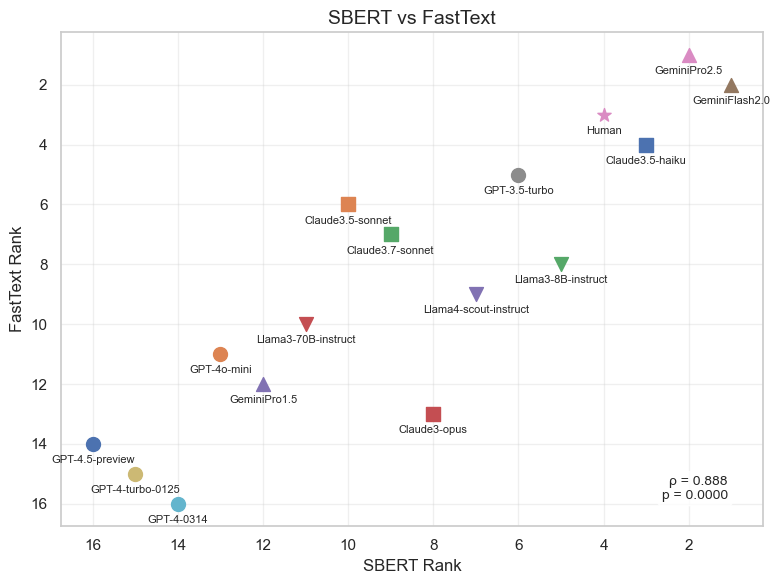

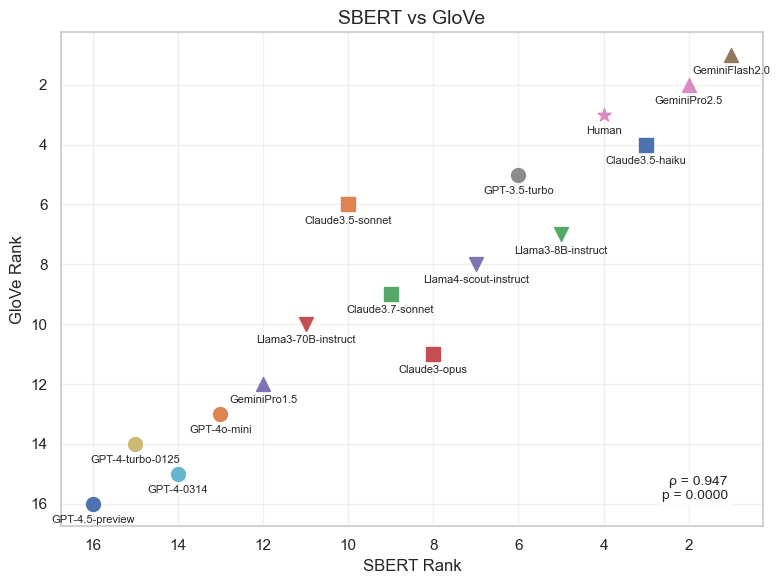

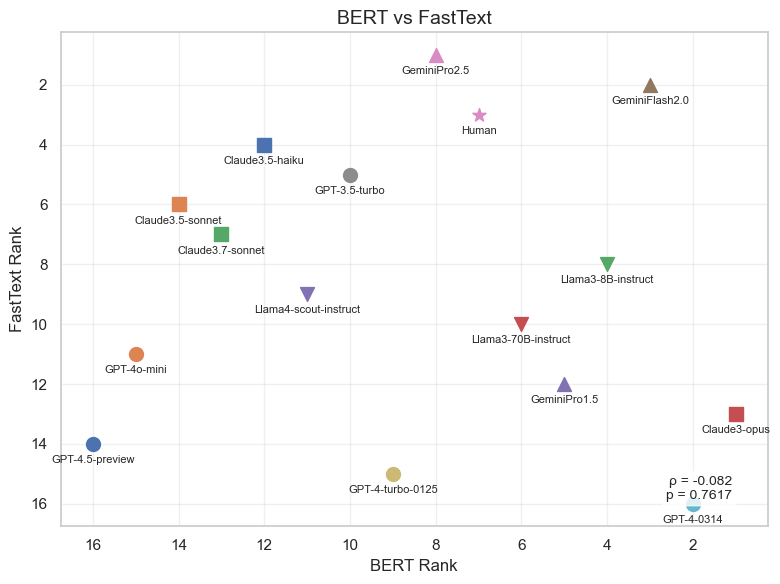

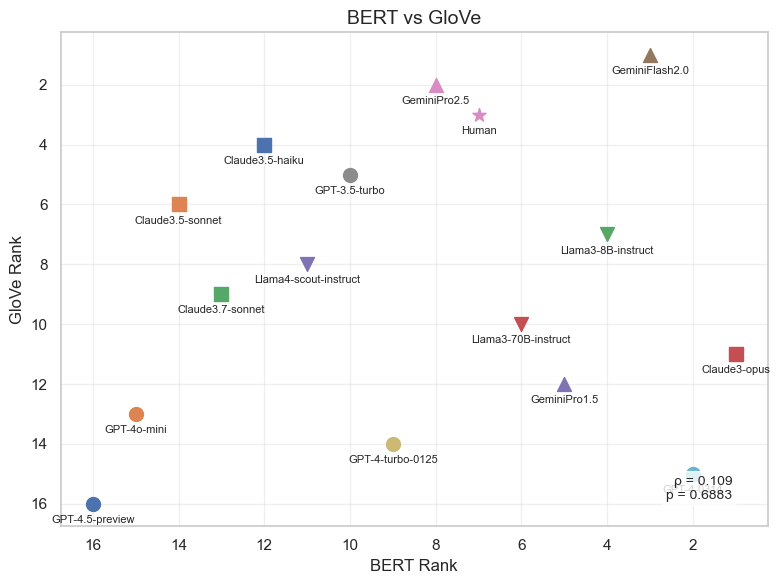

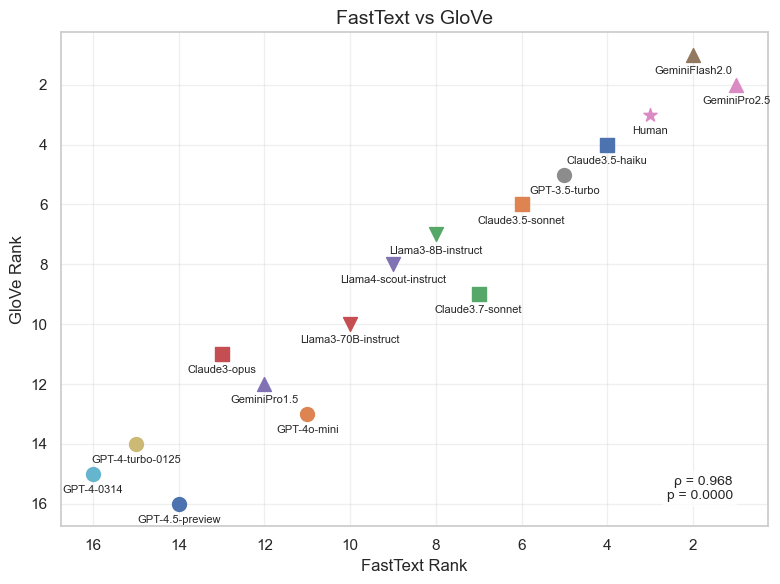

In [ ]:
# Create scatter plots comparing rankings between pairs of embedding methods
# Each plot shows how model rankings correlate across two different embedding types
pairs = list(itertools.combinations(novelty_types, 2))

# Generate a separate scatter plot for each embedding pair comparison
for idx, (type1, type2) in enumerate(pairs):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot each model as a point with model-specific marker and color
    for model in rankings_without[type1].index:
        # Get marker shape based on model family (GPT=circle, Claude=square, etc.)
        marker = get_marker(model)
        # Get color from predefined color palette
        color = color_dict.get(model, 'black')

        # Plot model's ranking position for both embedding types
        ax.scatter(
            rankings_without[type1][model],  # X-axis: ranking in first embedding method
            rankings_without[type2][model],  # Y-axis: ranking in second embedding method
            s=100,  
            color=color,
            alpha=1,
            marker=marker
        )
        
        ax.annotate(model, 
           (rankings_without[type1][model], rankings_without[type2][model]),
           fontsize=8, alpha=1,
           xytext=(0, -8), 
           textcoords='offset points',
           ha='center',  
           va='top')  
    
    # Calculate and display Spearman rank correlation coefficient
    rho, p = stats.spearmanr(rankings_without[type1], rankings_without[type2])
    ax.text(0.95, 0.05, f"ρ = {rho:.3f}\np = {p:.4f}", transform=ax.transAxes,
           fontsize=10, verticalalignment='bottom', horizontalalignment='right',
           bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax.set_xlabel(f'{novelty_labels[type1]} Rank', fontsize=12)
    ax.set_ylabel(f'{novelty_labels[type2]} Rank', fontsize=12)
    ax.set_title(f'{novelty_labels[type1]} vs {novelty_labels[type2]}', fontsize=14)
    
    # Add grid and invert axes so rank 1 (best) appears in top-right corner
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()  # Lower rank numbers (better) on the right
    ax.invert_yaxis()  # Lower rank numbers (better) on the top
    
    plt.tight_layout()
    
    filename = f'./figures/ranking_{novelty_labels[type1]}_vs_{novelty_labels[type2]}.png'
    #plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

## Ablation for Alignment vs Capability***

Average SBERT novelty for Low, Mid, and High temperatures (top 10 shown):
Temperature            High        Low        Mid
Model                                            
Claude3-opus            NaN  67.297623  67.314000
Claude3.5-haiku         NaN  69.263137  69.741473
Claude3.5-sonnet        NaN  66.878539  67.110547
Claude3.7-sonnet        NaN  66.907286  67.268676
GPT-3.5-turbo     70.369885  66.588645  67.661497
GPT-4-0314        65.503815  64.120443  64.499987
GPT-4-turbo-0125  65.025322  63.492210  63.987373
GPT-4.5-preview   63.445018  62.333421  62.494983
GPT-4o-mini       66.858056  65.113535  65.607365
GeminiFlash2.0    72.563855  71.310916  71.873220


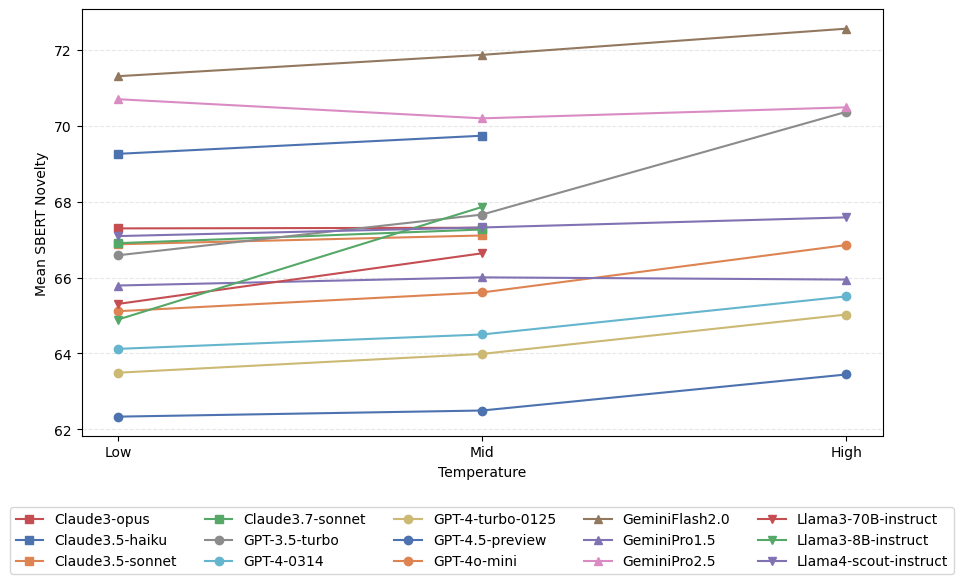

In [31]:
# Plot the transition of mean SBERT novelty across temperatures for each model
low_mid_high_df = results_df[results_df['Temperature'].isin(['Low', 'Mid', 'High'])].copy()

avg_low_mid_high = (
    low_mid_high_df
    .groupby(['Model', 'Temperature'])['sbert_novelty']
    .mean()
    .unstack()
)

# Determine which models have which temperatures
# Models need at least Low and Mid, but High is optional
temp_order = ['Low', 'Mid', 'High']
available_temps = [temp for temp in temp_order if temp in avg_low_mid_high.columns]

# Keep only models that have both Low and Mid data (High is optional)
avg_low_mid_high = avg_low_mid_high.dropna(subset=['Low', 'Mid'])

print("Average SBERT novelty for Low, Mid, and High temperatures (top 10 shown):")
print(avg_low_mid_high.head(10))

# Plot figure
plt.figure(figsize=(10, max(6, len(avg_low_mid_high) * 0.25)))

for model, row in avg_low_mid_high.iterrows():
    # Get available temperatures for this model (in order)
    model_temps = [temp for temp in temp_order if temp in available_temps and pd.notna(row.get(temp))]
    model_values = [row[temp] for temp in model_temps]
    model_color = color_dict.get(model, 'black')

    plt.plot(
        model_temps,
        model_values,
        marker=get_marker(model),
        linewidth=1.5,
        color=model_color,
        alpha=1,
        label=model
    )

plt.xlabel('Temperature')
plt.ylabel('Mean SBERT Novelty')
plt.xticks(available_temps)
plt.grid(axis='y', linestyle='--', alpha=0.3)

if len(avg_low_mid_high) <= 15:
    plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=5, frameon=True)

plt.tight_layout()

output_path = './figures_revise/sbert_novelty_low_mid_high.png'
import os
os.makedirs(os.path.dirname(output_path), exist_ok=True)
#plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()